# Importation des librairies

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set()

# Importation des fichiers

In [3]:
# Dispo alimentaire
dispo_alimentaire_2017 = pd.read_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 11/DisponibiliteAlimentaire_2017.csv')

# Population
population_2000_2018 = pd.read_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 11/Population_2000_2018.csv')

# Stabilité politique
stabilite_politique = pd.read_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 11/Political_stability.csv')

# Pouvoir d'achat
pouvoir_achat = taxes_import = pd.read_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 11/Pouvoir_achat.csv')

# Inflation
inflation_2017 = pd.read_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 11/Inflation_2017.csv')

# Production de poulet
prod_poulet = pd.read_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 11/Production_poulet_2017.csv')

# Importation
import_2017 = pd.read_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 11/Importation_2017.csv')
pourcent_import_nourriture = pd.read_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 11/Importation_nourriture.csv')

# Taxes sur importation
taxe_import = pd.read_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 11/WEF_GCIHH_TFDUTY_WIDEF.csv')

# Indice quantité d'importation
indice_quantite_import_2017 = pd.read_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 11/Indice_quantite_import_2017.csv')

# Environnement, social & gouvernance
esg = pd.read_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 11/esg.csv')

# Référentiel pays
#ref_pays = pd.read_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 11/referentiel-pays-et-territoires.csv', encoding='utf-8')
ref_pays = pd.read_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 11/ref_pays.csv')


# Standardisation des pays

In [4]:
# Les reférences pays REF_AREA des fichiers de la banque mondiale sont en ISO 3
ref_pays.head()

,Code Pays,Pays,Code M49,Code ISO2,Code ISO3,Année de début,Año de inicio
0,2,Afghanistan,4.00,AF,AFG,NaN,NaN
1,5100,Afrique,2.00,F5100,X06,NaN,NaN
2,51000,Afrique (exc commerce intracom),2.03,F51000,F51000,NaN,NaN
3,5104,Afrique australe,18.00,F5104,F5104,NaN,NaN
4,5102,Afrique centrale,17.00,F5102,F5102,NaN,NaN


In [5]:
# Les pays ne sont qu'avaec 3 lettres. Filtre pour ne conserver que ceux-ci
ref_pays = ref_pays[ref_pays['Code ISO3'].str.match(r'^[A-Z]{3}$')]
ref_pays.head()

,Code Pays,Pays,Code M49,Code ISO2,Code ISO3,Année de début,Año de inicio
0,2,Afghanistan,4.0,AF,AFG,NaN,NaN
10,202,Afrique du Sud,710.0,ZA,ZAF,NaN,NaN
17,3,Albanie,8.0,AL,ALB,NaN,NaN
18,4,Algérie,12.0,DZ,DZA,NaN,NaN
19,79,Allemagne,276.0,DE,DEU,NaN,NaN


In [6]:
ref_pays[ref_pays['Pays']=='Soudan']

,Code Pays,Pays,Code M49,Code ISO2,Code ISO3,Année de début,Año de inicio
338,276,Soudan,729.0,SD,SDN,2012.0,NaN


In [7]:
pays_fao = population_2000_2018['Zone']
pays_fao = pays_fao.drop_duplicates()
pays_fao = pd.DataFrame(pays_fao)
pays_fao.head()

,Zone
0,Afghanistan
19,Afrique du Sud
38,Albanie
57,Algérie
76,Allemagne


In [8]:
pays_fao[~pays_fao['Zone'].isin(ref_pays['Pays'])]

,Zone
3126,Pays-Bas
3552,"Sainte-Hélène, Ascension et Tristan da Cunha"
3845,Sint Maarten (partie néerlandaise)
3917,Soudan (ex)
4221,Turquie


In [9]:
ref_pays[~ref_pays['Pays'].isin(pays_fao['Zone'])]

,Code Pays,Pays,Code M49,Code ISO2,Code ISO3,Année de début,Año de inicio
37,30,Antarctique,10.0,AQ,ATA,NaN,NaN
41,24,Archipel des Chagos,86.0,IO,IOT,NaN,NaN
45,187,"Ascension, Sainte-Hélène et Tristan da Cunha",654.0,SH,SHN,NaN,NaN
157,271,Géorgie du Sud-et-Îles Sandwich du Sud,239.0,GS,SGS,NaN,NaN
166,274,Guernesey,831.0,GG,GGY,NaN,NaN
176,31,Île Bouvet,74.0,BV,BVT,NaN,NaN
177,42,Île Christmas,162.0,CX,CXR,NaN,NaN
179,92,Île Heard et Îles McDonald,334.0,HM,HMD,NaN,NaN
180,111,Île Johnston,396.0,JT,JTN,NaN,NaN
181,139,Île Midway,488.0,MI,MID,NaN,NaN


In [10]:
# Changement manuel des 5 pays concernés
liste = {'Pays-Bas (Royaume des)' : 'Pays-Bas',
         'Ascension, Sainte-Hélène et Tristan da Cunha' : 'Sainte-Hélène, Ascension et Tristan da Cunha',
         'Sint Maarten (partie néerlandaise)' : 'Sint Maarten (partie néerlandaise)',
         'Türkiye' : 'Turquie'
        }

In [11]:
ref_pays['Pays'] = ref_pays['Pays'].replace(liste)

In [12]:
pays_fao[~pays_fao['Zone'].isin(ref_pays['Pays'])]

,Zone
3845,Sint Maarten (partie néerlandaise)
3917,Soudan (ex)


In [13]:
print(repr(pays_fao.loc[3845, 'Zone']))
print(repr(ref_pays[ref_pays['Pays'].str.contains('Sint', na=False)]['Pays'].iloc[0]))

'Sint Maarten  (partie néerlandaise)'
'Sint Maarten (partie néerlandaise)'


In [14]:
ref_pays[~ref_pays['Pays'].isin(pays_fao['Zone'])]

,Code Pays,Pays,Code M49,Code ISO2,Code ISO3,Année de début,Año de inicio
37,30,Antarctique,10.0,AQ,ATA,NaN,NaN
41,24,Archipel des Chagos,86.0,IO,IOT,NaN,NaN
157,271,Géorgie du Sud-et-Îles Sandwich du Sud,239.0,GS,SGS,NaN,NaN
166,274,Guernesey,831.0,GG,GGY,NaN,NaN
176,31,Île Bouvet,74.0,BV,BVT,NaN,NaN
177,42,Île Christmas,162.0,CX,CXR,NaN,NaN
179,92,Île Heard et Îles McDonald,334.0,HM,HMD,NaN,NaN
180,111,Île Johnston,396.0,JT,JTN,NaN,NaN
181,139,Île Midway,488.0,MI,MID,NaN,NaN
182,161,Île Norfolk,574.0,NF,NFK,NaN,NaN


In [15]:
# Conserver les colonnes nécessaires
ref_pays = ref_pays[['Pays', 'Code ISO3']]
ref_pays.head()

,Pays,Code ISO3
0,Afghanistan,AFG
10,Afrique du Sud,ZAF
17,Albanie,ALB
18,Algérie,DZA
19,Allemagne,DEU


# Préparation des fichiers

## Dispo alimentaire

In [16]:
dispo_alimentaire_2017.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.0,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.0,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.0,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.0,S,Données standardisées


In [17]:
dispo_alimentaire_2017.count()

Code Domaine              176600
Domaine                   176600
Code zone                 176600
Zone                      176600
Code Élément              176600
Élément                   176600
Code Produit              176600
Produit                   176600
Code année                176600
Année                     176600
Unité                     176600
Valeur                    176600
Symbole                   176600
Description du Symbole    176600
dtype: int64

In [18]:
dispo_alimentaire_2017.dtypes

Code Domaine               object
Domaine                    object
Code zone                   int64
Zone                       object
Code Élément                int64
Élément                    object
Code Produit                int64
Produit                    object
Code année                  int64
Année                       int64
Unité                      object
Valeur                    float64
Symbole                    object
Description du Symbole     object
dtype: object

In [19]:
dispo_alimentaire_2017['Produit'].unique()

array(['Blé et produits', 'Riz et produits', 'Orge et produits',
       'Maïs et produits', 'Seigle et produits', 'Avoine',
       'Millet et produits', 'Sorgho et produits', 'Céréales, Autres',
       'Pommes de Terre et produits', 'Ignames', 'Racines nda',
       'Sucre, canne', 'Sucre, betterave', 'Sucre Eq Brut',
       'Edulcorants Autres', 'Miel', 'Haricots', 'Pois',
       'Légumineuses Autres et produits', 'Noix et produits', 'Soja',
       'Arachides Decortiquees', 'Graines de tournesol',
       'Graines Colza/Moutarde', 'Graines de coton', 'Coco (Incl Coprah)',
       'Sésame', 'Olives', 'Plantes Oleiferes, Autre', 'Huile de Soja',
       "Huile d'Arachide", 'Huile de Tournesol',
       'Huile de Colza&Moutarde', 'Huile Graines de Coton',
       'Huile de Palmistes', 'Huile de Palme', 'Huile de Coco',
       'Huile de Sésame', "Huile d'Olive", 'Huile de Son de Riz',
       'Huile de Germe de Maïs', 'Huil Plantes Oleif Autr',
       'Tomates et produits', 'Oignons', 'Légumes, 

In [20]:
# Conserver uniquement la viande de voiaille

dispo_alimentaire_2017 = dispo_alimentaire_2017[dispo_alimentaire_2017['Produit'] == 'Viande de Volailles']
dispo_alimentaire_2017.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
651,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2734,Viande de Volailles,2017,2017,Milliers de tonnes,28.0,S,Données standardisées
652,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2734,Viande de Volailles,2017,2017,Milliers de tonnes,29.0,S,Données standardisées
653,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2734,Viande de Volailles,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
654,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2734,Viande de Volailles,2017,2017,Milliers de tonnes,57.0,S,Données standardisées
655,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5123,Pertes,2734,Viande de Volailles,2017,2017,Milliers de tonnes,2.0,S,Données standardisées


In [21]:
# Supprimer les colonnes inutiles

liste = ['Code Domaine', 'Domaine', 'Code zone', 'Code Élément', 'Code Produit', 'Code année', 'Symbole', 'Description du Symbole']
dispo_alimentaire_2017 = dispo_alimentaire_2017.drop(columns=liste).reset_index(drop=True)
dispo_alimentaire_2017.head()

,Zone,Élément,Produit,Année,Unité,Valeur
0,Afghanistan,Production,Viande de Volailles,2017,Milliers de tonnes,28.0
1,Afghanistan,Importations - Quantité,Viande de Volailles,2017,Milliers de tonnes,29.0
2,Afghanistan,Variation de stock,Viande de Volailles,2017,Milliers de tonnes,0.0
3,Afghanistan,Disponibilité intérieure,Viande de Volailles,2017,Milliers de tonnes,57.0
4,Afghanistan,Pertes,Viande de Volailles,2017,Milliers de tonnes,2.0


In [22]:
dispo_alimentaire_2017['Zone'].unique()

array(['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Allemagne',
       'Angola', 'Antigua-et-Barbuda', 'Arabie saoudite', 'Argentine',
       'Arménie', 'Australie', 'Autriche', 'Azerbaïdjan', 'Bahamas',
       'Bangladesh', 'Barbade', 'Bélarus', 'Belgique', 'Belize', 'Bénin',
       'Bolivie (État plurinational de)', 'Bosnie-Herzégovine',
       'Botswana', 'Brésil', 'Bulgarie', 'Burkina Faso', 'Cabo Verde',
       'Cambodge', 'Cameroun', 'Canada', 'Chili',
       'Chine - RAS de Hong-Kong', 'Chine - RAS de Macao',
       'Chine, continentale', 'Chine, Taiwan Province de', 'Chypre',
       'Colombie', 'Congo', 'Costa Rica', "Côte d'Ivoire", 'Croatie',
       'Cuba', 'Danemark', 'Djibouti', 'Dominique', 'Égypte',
       'El Salvador', 'Émirats arabes unis', 'Équateur', 'Espagne',
       'Estonie', 'Eswatini', "États-Unis d'Amérique", 'Éthiopie',
       'Fédération de Russie', 'Fidji', 'Finlande', 'France', 'Gabon',
       'Gambie', 'Géorgie', 'Ghana', 'Grèce', 'Grenade', 'Gu

In [23]:
dispo_alimentaire_2017['Année'].unique()

array([2017])

In [24]:
dispo_alimentaire_2017['Élément'].unique()

array(['Production', 'Importations - Quantité', 'Variation de stock',
       'Disponibilité intérieure', 'Pertes', 'Résidus', 'Nourriture',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Exportations - Quantité', 'Alimentation pour touristes',
       'Traitement', 'Autres utilisations (non alimentaire)',
       'Aliments pour animaux', 'Semences'], dtype=object)

In [25]:
dispo_alimentaire_2017[dispo_alimentaire_2017['Élément'].isna()]

,Zone,Élément,Produit,Année,Unité,Valeur


In [26]:
# Conserver Production, importations, Disponibilité intérieur, Exportation

liste = ['Variation de stock', 'Pertes', 'Résidus', 'Nourriture',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
        'Alimentation pour touristes',
       'Traitement', 'Autres utilisations (non alimentaire)',
       'Aliments pour animaux', 'Semences']
dispo_alimentaire_2017 = dispo_alimentaire_2017[~dispo_alimentaire_2017['Élément'].isin(liste)]
dispo_alimentaire_2017.head()

,Zone,Élément,Produit,Année,Unité,Valeur
0,Afghanistan,Production,Viande de Volailles,2017,Milliers de tonnes,28.0
1,Afghanistan,Importations - Quantité,Viande de Volailles,2017,Milliers de tonnes,29.0
3,Afghanistan,Disponibilité intérieure,Viande de Volailles,2017,Milliers de tonnes,57.0
11,Afrique du Sud,Production,Viande de Volailles,2017,Milliers de tonnes,1667.0
12,Afrique du Sud,Importations - Quantité,Viande de Volailles,2017,Milliers de tonnes,514.0


In [27]:
# Pivoter la table

dispo_alimentaire_2017 = dispo_alimentaire_2017.pivot_table(index=['Zone', 'Année'], values='Valeur', columns='Élément')
dispo_alimentaire_2017.head()

,Élément,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production
Zone,Année,,,,
Afghanistan,2017,57.0,NaN,29.0,28.0
Afrique du Sud,2017,2118.0,63.0,514.0,1667.0
Albanie,2017,47.0,0.0,38.0,13.0
Algérie,2017,277.0,0.0,2.0,275.0
Allemagne,2017,1739.0,646.0,842.0,1514.0


In [28]:
dispo_alimentaire_2017.columns.get_level_values(0)
dispo_alimentaire_2017 = dispo_alimentaire_2017.rename(columns={
    'Disponibilité intérieure' : 'Disponibiité intérieur (viande de volailles, en milliers de tonnes',
    'Exportations - Quantité' : 'Exportations - Quantité (viande volailles, en milliers de tonnes',
    'Importations - Quantité' : 'Importations - Quantité (viande de volailles, en milliers de tonnes',
    'Production' : 'Production (viande de volailles, en milliers de tonnes)',
})
dispo_alimentaire_2017.head()

,Élément,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes","Importations - Quantité (viande de volailles, en milliers de tonnes","Production (viande de volailles, en milliers de tonnes)"
Zone,Année,,,,
Afghanistan,2017,57.0,NaN,29.0,28.0
Afrique du Sud,2017,2118.0,63.0,514.0,1667.0
Albanie,2017,47.0,0.0,38.0,13.0
Algérie,2017,277.0,0.0,2.0,275.0
Allemagne,2017,1739.0,646.0,842.0,1514.0


In [29]:
dispo_alimentaire_2017.columns.name=None
dispo_alimentaire_2017.reset_index(inplace=True)
dispo_alimentaire_2017.head()

,Zone,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes","Importations - Quantité (viande de volailles, en milliers de tonnes","Production (viande de volailles, en milliers de tonnes)"
0,Afghanistan,2017,57.0,NaN,29.0,28.0
1,Afrique du Sud,2017,2118.0,63.0,514.0,1667.0
2,Albanie,2017,47.0,0.0,38.0,13.0
3,Algérie,2017,277.0,0.0,2.0,275.0
4,Allemagne,2017,1739.0,646.0,842.0,1514.0


In [30]:
dispo_alimentaire_2017.describe()

,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes","Importations - Quantité (viande de volailles, en milliers de tonnes","Production (viande de volailles, en milliers de tonnes)"
count,170.0,170.000000,135.000000,170.000000,168.000000
mean,2017.0,687.594118,132.185185,89.529412,725.190476
std,0.0,2187.184747,513.784440,186.669983,2501.457125
min,2017.0,2.000000,0.000000,0.000000,0.000000
25%,2017.0,30.500000,0.000000,3.000000,13.750000
50%,2017.0,100.000000,3.000000,16.000000,70.000000
75%,2017.0,368.250000,32.000000,81.250000,409.750000
max,2017.0,18266.000000,4223.000000,1069.000000,21914.000000


In [31]:
# Renommer Zone en pays
dispo_alimentaire_2017 = dispo_alimentaire_2017.rename(columns={'Zone' : 'Pays'})
dispo_alimentaire_2017.head()

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes","Importations - Quantité (viande de volailles, en milliers de tonnes","Production (viande de volailles, en milliers de tonnes)"
0,Afghanistan,2017,57.0,NaN,29.0,28.0
1,Afrique du Sud,2017,2118.0,63.0,514.0,1667.0
2,Albanie,2017,47.0,0.0,38.0,13.0
3,Algérie,2017,277.0,0.0,2.0,275.0
4,Allemagne,2017,1739.0,646.0,842.0,1514.0


In [32]:
# Vérification des pays sur le référentiel
dispo_alimentaire_2017[~dispo_alimentaire_2017['Pays'].isin(ref_pays['Pays'])]

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes","Importations - Quantité (viande de volailles, en milliers de tonnes","Production (viande de volailles, en milliers de tonnes)"


## Population

In [33]:
population_2000_2018.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680.871,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726.684,X,Sources internationales sûres,NaN


In [34]:
# Conserver l'année 2017 

population_2017 = population_2000_2018[population_2000_2018['Année'] == 2017]
population_2017.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
17,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,36296.113,X,Sources internationales sûres,NaN
36,OA,Séries temporelles annuelles,202,Afrique du Sud,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,57009.756,X,Sources internationales sûres,NaN
55,OA,Séries temporelles annuelles,3,Albanie,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,2884.169,X,Sources internationales sûres,NaN
74,OA,Séries temporelles annuelles,4,Algérie,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,41389.189,X,Sources internationales sûres,NaN
93,OA,Séries temporelles annuelles,79,Allemagne,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,82658.409,X,Sources internationales sûres,NaN


In [35]:
# Transformation de la valeur en million

population_2017 = population_2017.copy()
population_2017['Valeur'] = population_2017['Valeur'] * 1000
population_2017.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
17,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,36296113.0,X,Sources internationales sûres,NaN
36,OA,Séries temporelles annuelles,202,Afrique du Sud,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,57009756.0,X,Sources internationales sûres,NaN
55,OA,Séries temporelles annuelles,3,Albanie,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,2884169.0,X,Sources internationales sûres,NaN
74,OA,Séries temporelles annuelles,4,Algérie,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,41389189.0,X,Sources internationales sûres,NaN
93,OA,Séries temporelles annuelles,79,Allemagne,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,82658409.0,X,Sources internationales sûres,NaN


In [36]:
# Changer la colonne valeiur en 'population'
population_2017 = population_2017.rename(columns={'Valeur' : 'Population totale'})
population_2017.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Population totale,Symbole,Description du Symbole,Note
17,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,36296113.0,X,Sources internationales sûres,NaN
36,OA,Séries temporelles annuelles,202,Afrique du Sud,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,57009756.0,X,Sources internationales sûres,NaN
55,OA,Séries temporelles annuelles,3,Albanie,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,2884169.0,X,Sources internationales sûres,NaN
74,OA,Séries temporelles annuelles,4,Algérie,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,41389189.0,X,Sources internationales sûres,NaN
93,OA,Séries temporelles annuelles,79,Allemagne,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,82658409.0,X,Sources internationales sûres,NaN


In [37]:
# Conserver les colonnes zone, Année, Population totale
population_2017 = population_2017[['Zone', 'Année', 'Population totale']]
population_2017.head()

,Zone,Année,Population totale
17,Afghanistan,2017,36296113.0
36,Afrique du Sud,2017,57009756.0
55,Albanie,2017,2884169.0
74,Algérie,2017,41389189.0
93,Allemagne,2017,82658409.0


In [38]:
# Renommer zone en pays
population_2017 = population_2017.rename(columns={'Zone' : 'Pays'})
population_2017.head()

,Pays,Année,Population totale
17,Afghanistan,2017,36296113.0
36,Afrique du Sud,2017,57009756.0
55,Albanie,2017,2884169.0
74,Algérie,2017,41389189.0
93,Allemagne,2017,82658409.0


In [39]:
population_2017.count()

Pays                 236
Année                236
Population totale    236
dtype: int64

In [40]:
# vérification des pays par rapport au référentiel
population_2017[~population_2017['Pays'].isin(ref_pays['Pays'])]

,Pays,Année,Population totale
3851,Sint Maarten (partie néerlandaise),2017,41444.0


## Stabilité politique

In [41]:
# Vue du fichier

stabilite_politique.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,SVN,WB_WDI_PV_EST,_T,_T,_T,IX,...,0.965773,0.947492,0.979142,0.866365,0.894267,0.801586,0.701468,0.755585,0.709335,0.818633
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,LTU,WB_WDI_PV_EST,_T,_T,_T,IX,...,0.742136,0.749750,0.814721,0.765566,0.729237,0.770624,0.921477,0.809847,0.653033,0.742112
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,BGR,WB_WDI_PV_EST,_T,_T,_T,IX,...,0.078541,0.010425,0.068279,0.321380,0.444411,0.561284,0.401631,0.364739,0.313429,0.341861
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,IDN,WB_WDI_PV_EST,_T,_T,_T,IX,...,-0.416824,-0.619956,-0.379700,-0.504939,-0.552034,-0.502143,-0.462311,-0.531449,-0.553894,-0.404375
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,HRV,WB_WDI_PV_EST,_T,_T,_T,IX,...,0.619112,0.586514,0.654191,0.681906,0.793678,0.685511,0.607283,0.621596,0.672563,0.597712


In [42]:
# Nombre de lignes / colonnes

stabilite_politique.shape

(205, 66)

In [43]:
# Conserver REF_AREA et 2017

stabilite_politique_2017 = stabilite_politique[['REF_AREA', '2017']].copy()
stabilite_politique_2017['Année'] = 2017
stabilite_politique_2017 = stabilite_politique_2017.rename(columns={'2017' : 'Stabilité politique'})

In [44]:
ref_pays.head()

,Pays,Code ISO3
0,Afghanistan,AFG
10,Afrique du Sud,ZAF
17,Albanie,ALB
18,Algérie,DZA
19,Allemagne,DEU


In [45]:
stabilite_politique_2017.head()

,REF_AREA,Stabilité politique,Année
0,SVN,0.866365,2017
1,LTU,0.765566,2017
2,BGR,0.321380,2017
3,IDN,-0.504939,2017
4,HRV,0.681906,2017


In [46]:
# Intégrer le nom des pays
stabilite_politique_2017 = stabilite_politique_2017.merge(ref_pays, left_on='REF_AREA', right_on='Code ISO3', how='left')
stabilite_politique_2017 = stabilite_politique_2017.rename(columns={'NOM_COURT' : 'Zone'})
stabilite_politique_2017.head()
                                                    

,REF_AREA,Stabilité politique,Année,Pays,Code ISO3
0,SVN,0.866365,2017,Slovénie,SVN
1,LTU,0.765566,2017,Lituanie,LTU
2,BGR,0.321380,2017,Bulgarie,BGR
3,IDN,-0.504939,2017,Indonésie,IDN
4,HRV,0.681906,2017,Croatie,HRV


In [47]:
# Describe sur la stabilité politique
stabilite_politique_2017['Stabilité politique'].describe()

count    205.000000
mean      -0.025669
std        1.000878
min       -2.934317
25%       -0.642760
50%        0.048514
75%        0.783372
max        1.927584
Name: Stabilité politique, dtype: float64

In [48]:
# Vérification des NaN
stabilite_politique_2017.count()

REF_AREA               205
Stabilité politique    205
Année                  205
Pays                   204
Code ISO3              204
dtype: int64

In [49]:
stabilite_politique_2017[stabilite_politique_2017['Pays'].isna()]

,REF_AREA,Stabilité politique,Année,Pays,Code ISO3
140,XKX,-0.244493,2017,NaN,NaN


In [50]:
# Correspond au Kosovo, ne pas conserver

In [51]:
stabilite_politique_2017 = stabilite_politique_2017.drop(columns=['REF_AREA', 'Code ISO3'])
stabilite_politique_2017 = stabilite_politique_2017.dropna(subset='Pays')
stabilite_politique_2017.count()

Stabilité politique    204
Année                  204
Pays                   204
dtype: int64

In [52]:
stabilite_politique_2017.head()

,Stabilité politique,Année,Pays
0,0.866365,2017,Slovénie
1,0.765566,2017,Lituanie
2,0.321380,2017,Bulgarie
3,-0.504939,2017,Indonésie
4,0.681906,2017,Croatie


In [53]:
# Vérification des pays sur le référentiel
stabilite_politique_2017[~stabilite_politique_2017['Pays'].isin(ref_pays['Pays'])]

,Stabilité politique,Année,Pays


## Pouvoir d'achat

In [54]:
pouvoir_achat.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ISR,WB_WDI_NY_GDP_PCAP_CD,_T,_T,_T,USD,...,36213.104148,37671.538914,41138.470964,42362.665275,44250.631363,44575.571905,52270.904024,54949.621556,52003.720073,54176.684438
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ARG,WB_WDI_NY_GDP_PCAP_CD,_T,_T,_T,USD,...,13679.626498,12699.962314,14532.500931,11752.799892,9955.974787,8535.599380,10738.017922,13962.189409,14261.846567,13969.783660
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,SDN,WB_WDI_NY_GDP_PCAP_CD,_T,_T,_T,USD,...,1292.379639,1033.215942,966.505676,731.027466,709.975281,577.795227,712.122009,1046.240845,797.283447,984.607666
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,COD,WB_WDI_NY_GDP_PCAP_CD,_T,_T,_T,USD,...,495.826633,459.765037,431.052559,518.169627,504.004191,486.425573,595.743074,687.738588,660.212052,649.383339
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MAC,WB_WDI_NY_GDP_PCAP_CD,_T,_T,_T,USD,...,69902.960574,68911.675592,77570.987617,83588.287501,81882.696452,36883.665258,44884.896160,36806.891255,67216.363111,72004.743702


In [55]:
pouvoir_achat.shape

(262, 106)

In [56]:
# Conserver REF_AREA et 2017

pouvoir_achat_2017 = pouvoir_achat[['REF_AREA', '2017']]
pouvoir_achat_2017.head()

,REF_AREA,2017
0,ISR,41138.470964
1,ARG,14532.500931
2,SDN,966.505676
3,COD,431.052559
4,MAC,77570.987617


In [57]:
# Vérification des NaN
pouvoir_achat_2017.count()

REF_AREA    262
2017        259
dtype: int64

In [58]:
pouvoir_achat_2017[pouvoir_achat_2017['2017'].isna()]

,REF_AREA,2017
99,ERI,NaN
102,SSD,NaN
149,MAF,NaN


In [59]:
# Vérification de la correspondance des pays avec NaN
ref_pays[ref_pays['Code ISO3'].isin(['ERI', 'SSD', 'MAF'])]['Pays']

118                           Érythrée
320    Saint-Martin (partie française)
340                      Soudan du Sud
Name: Pays, dtype: object

In [60]:
# Intégrer les noms des pays à la place des REF_AREA et intégrer la variable année
pouvoir_achat_2017 = pouvoir_achat_2017.merge(ref_pays, left_on='REF_AREA', right_on='Code ISO3', how='left')
pouvoir_achat_2017 = pouvoir_achat_2017.rename(columns={'2017': 'PIB par habitant (en USD)'})
pouvoir_achat_2017['Année'] = 2017
pouvoir_achat_2017.head()

,REF_AREA,PIB par habitant (en USD),Pays,Code ISO3,Année
0,ISR,41138.470964,Israël,ISR,2017
1,ARG,14532.500931,Argentine,ARG,2017
2,SDN,966.505676,Soudan,SDN,2017
3,COD,431.052559,République démocratique du Congo,COD,2017
4,MAC,77570.987617,Chine - RAS de Macao,MAC,2017


In [61]:
pouvoir_achat_2017['Pays'].isna().sum()

np.int64(50)

In [62]:
pouvoir_achat_2017[pouvoir_achat_2017['Pays'].isna()]

,REF_AREA,PIB par habitant (en USD),Pays,Code ISO3,Année
17,ECS,23814.119703,NaN,NaN,2017
26,MNA,2859.855602,NaN,NaN,2017
33,IDB,1804.505594,NaN,NaN,2017
41,CSS,13671.137763,NaN,NaN,2017
45,TLA,8918.302513,NaN,NaN,2017
48,HIC,38776.561595,NaN,NaN,2017
50,SSA,1641.392400,NaN,NaN,2017
54,EAR,3457.649432,NaN,NaN,2017
57,LTE,9138.441345,NaN,NaN,2017
66,TSA,1956.067076,NaN,NaN,2017


In [63]:
# Correspond à des groupements, des régions etc... A supprimer ainsi que les valaurs manquantes des 3 pays vu précédemment

In [64]:
pouvoir_achat_2017 = pouvoir_achat_2017.dropna(subset='Pays')
pouvoir_achat_2017.shape

(212, 5)

In [65]:
# Supprimer les colonnes inutiles
pouvoir_achat_2017 = pouvoir_achat_2017.drop(columns=['REF_AREA', 'Code ISO3'])
pouvoir_achat_2017.head()

,PIB par habitant (en USD),Pays,Année
0,41138.470964,Israël,2017
1,14532.500931,Argentine,2017
2,966.505676,Soudan,2017
3,431.052559,République démocratique du Congo,2017
4,77570.987617,Chine - RAS de Macao,2017


In [66]:
pouvoir_achat_2017.count()

PIB par habitant (en USD)    209
Pays                         212
Année                        212
dtype: int64

In [67]:
# Vérification des pays sur le référentiel
pouvoir_achat_2017[~pouvoir_achat_2017['Pays'].isin(ref_pays['Pays'])]

,PIB par habitant (en USD),Pays,Année


## Inflation

In [68]:
# Vue du fichier
inflation_2017.head()

,Code Domaine,Domaine,Code zone (M49),Zone,Code année,Année,Code Produit,Produit,Code Mois,Mois,Code Élément,Élément,Unité,Valeur,Symbole,Description du Symbole,Note
0,CP,Indices de Prix à la Consommation,4,Afghanistan,2017,2017,23014,Food price inflation,7001,Janvier,6121,Valeur,%,4.730651,E,Valeur estimée,NaN
1,CP,Indices de Prix à la Consommation,4,Afghanistan,2017,2017,23014,Food price inflation,7002,Février,6121,Valeur,%,4.553673,E,Valeur estimée,NaN
2,CP,Indices de Prix à la Consommation,4,Afghanistan,2017,2017,23014,Food price inflation,7003,Mars,6121,Valeur,%,10.028383,E,Valeur estimée,NaN
3,CP,Indices de Prix à la Consommation,4,Afghanistan,2017,2017,23014,Food price inflation,7004,Avril,6121,Valeur,%,9.367880,E,Valeur estimée,NaN
4,CP,Indices de Prix à la Consommation,4,Afghanistan,2017,2017,23014,Food price inflation,7005,Mai,6121,Valeur,%,10.723921,E,Valeur estimée,NaN


In [69]:
# Vérification des NaN
inflation_2017.count()

Code Domaine              2420
Domaine                   2420
Code zone (M49)           2420
Zone                      2420
Code année                2420
Année                     2420
Code Produit              2420
Produit                   2420
Code Mois                 2420
Mois                      2420
Code Élément              2420
Élément                   2420
Unité                     2420
Valeur                    2420
Symbole                   2420
Description du Symbole    2420
Note                         0
dtype: int64

In [70]:
# Vérification de la variable produit
inflation_2017['Produit'].unique()

array(['Food price inflation'], dtype=object)

In [71]:
# Conserver Zone, Année, Valeur


inflation_2017 = inflation_2017[['Zone', 'Année', 'Valeur']]
inflation_2017.head()

,Zone,Année,Valeur
0,Afghanistan,2017,4.730651
1,Afghanistan,2017,4.553673
2,Afghanistan,2017,10.028383
3,Afghanistan,2017,9.367880
4,Afghanistan,2017,10.723921


In [72]:
# Renommer valeur en valeur (en %)
inflation_2017 = inflation_2017.rename(columns={'Valeur' : 'Food price inflation (en %)'})
inflation_2017.head()

,Zone,Année,Food price inflation (en %)
0,Afghanistan,2017,4.730651
1,Afghanistan,2017,4.553673
2,Afghanistan,2017,10.028383
3,Afghanistan,2017,9.367880
4,Afghanistan,2017,10.723921


In [73]:
# Regrouper par pays avec la moyenne des valeurs

inflation_2017 = inflation_2017.groupby(['Zone', 'Année'])['Food price inflation (en %)'].mean().reset_index()
inflation_2017.head()

,Zone,Année,Food price inflation (en %)
0,Afghanistan,2017,6.957529
1,Afrique du Sud,2017,6.902635
2,Albanie,2017,3.913865
3,Algérie,2017,5.040496
4,Allemagne,2017,2.762495


In [74]:
# Renommer Zone en pays
inflation_2017 = inflation_2017.rename(columns={'Zone' : 'Pays'})
inflation_2017.head()

,Pays,Année,Food price inflation (en %)
0,Afghanistan,2017,6.957529
1,Afrique du Sud,2017,6.902635
2,Albanie,2017,3.913865
3,Algérie,2017,5.040496
4,Allemagne,2017,2.762495


In [75]:
inflation_2017['Food price inflation (en %)'].describe()

count    203.000000
mean       7.871670
std       37.743249
min       -3.718112
25%        0.580473
50%        2.463690
75%        5.749607
max      480.863389
Name: Food price inflation (en %), dtype: float64

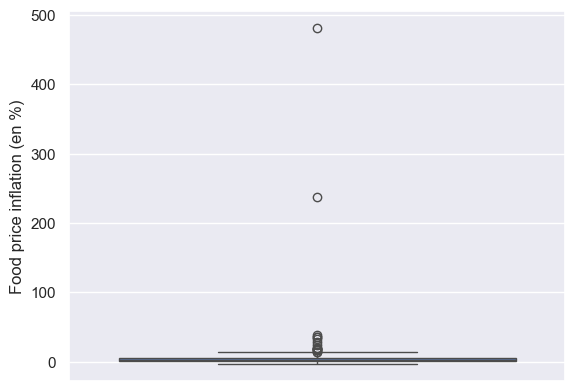

In [76]:
sns.boxplot(data=inflation_2017, y='Food price inflation (en %)')
plt.show()

In [77]:
inflation_2017.count()

Pays                           203
Année                          203
Food price inflation (en %)    203
dtype: int64

In [78]:
# Vérification des pays sur le référentiel
inflation_2017[~inflation_2017['Pays'].isin(ref_pays['Pays'])]

,Pays,Année,Food price inflation (en %)
136,Pays-Bas (Royaume des),2017,2.664325
184,Türkiye,2017,12.727915


In [79]:
# Changer les noms de ces pays
liste = {'Pays-Bas (Royaume des)' : 'Pays-Bas',
         'Türkiye' : 'Turquie'
        }
inflation_2017 = inflation_2017.replace(liste)

In [80]:
inflation_2017[~inflation_2017['Pays'].isin(ref_pays['Pays'])]

,Pays,Année,Food price inflation (en %)


## Production de poulet

In [81]:
prod_poulet.head()

,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit (CPC),Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,QCL,Cultures et produits animaux,4,Afghanistan,5510,Production,21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,tonnes,27637.84,I,Valeur imputée par une agence réceptrice,NaN
1,QCL,Cultures et produits animaux,710,Afrique du Sud,5510,Production,21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,tonnes,1658159.00,A,Chiffre officiel,NaN
2,QCL,Cultures et produits animaux,8,Albanie,5510,Production,21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,tonnes,12912.00,A,Chiffre officiel,NaN
3,QCL,Cultures et produits animaux,12,Algérie,5510,Production,21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,tonnes,364252.17,I,Valeur imputée par une agence réceptrice,NaN
4,QCL,Cultures et produits animaux,276,Allemagne,5510,Production,21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,tonnes,1009565.00,A,Chiffre officiel,NaN


In [82]:
prod_poulet.count()

Code Domaine              195
Domaine                   195
Code zone (M49)           195
Zone                      195
Code Élément              195
Élément                   195
Code Produit (CPC)        195
Produit                   195
Code année                195
Année                     195
Unité                     195
Valeur                    195
Symbole                   195
Description du Symbole    195
Note                        4
dtype: int64

In [83]:
prod_poulet['Élément'].unique()

array(['Production'], dtype=object)

In [84]:
prod_poulet['Unité'].unique()

array(['tonnes'], dtype=object)

In [85]:
# Conserver Zone, Année, Valeur
prod_poulet_2017 = prod_poulet[['Zone', 'Année', 'Valeur']]
prod_poulet_2017.head()

,Zone,Année,Valeur
0,Afghanistan,2017,27637.84
1,Afrique du Sud,2017,1658159.00
2,Albanie,2017,12912.00
3,Algérie,2017,364252.17
4,Allemagne,2017,1009565.00


In [86]:
# Renommer colonne Valeur en 'Production viande, poulet, fraîche ou réfrigérée (en tonnes)' et Zone en Pays
prod_poulet_2017 = prod_poulet_2017.rename(columns={'Valeur' : 'Production viande, poulet, fraîche ou réfrigérée (en tonnes)',
                                                   'Zone' : 'Pays'})
prod_poulet_2017.head()                                                    

,Pays,Année,"Production viande, poulet, fraîche ou réfrigérée (en tonnes)"
0,Afghanistan,2017,27637.84
1,Afrique du Sud,2017,1658159.00
2,Albanie,2017,12912.00
3,Algérie,2017,364252.17
4,Allemagne,2017,1009565.00


In [87]:
prod_poulet_2017['Production viande, poulet, fraîche ou réfrigérée (en tonnes)'].describe()

count    1.950000e+02
mean     6.444021e+05
std      2.218251e+06
min      4.030000e+00
25%      8.080025e+03
50%      6.338300e+04
75%      2.730770e+05
max      1.914057e+07
Name: Production viande, poulet, fraîche ou réfrigérée (en tonnes), dtype: float64

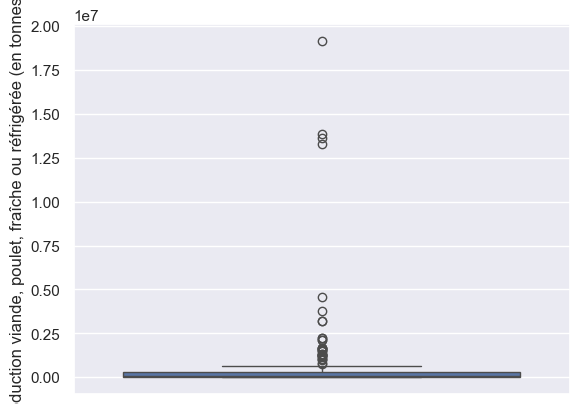

In [88]:
sns.boxplot(data=prod_poulet_2017, y='Production viande, poulet, fraîche ou réfrigérée (en tonnes)')
plt.show()

In [89]:
prod_poulet_2017.shape

(195, 3)

In [90]:
prod_poulet_2017['Pays'].duplicated().sum()

np.int64(0)

In [91]:
prod_poulet_2017.count()

Pays                                                            195
Année                                                           195
Production viande, poulet, fraîche ou réfrigérée (en tonnes)    195
dtype: int64

In [92]:
# Vérification des pays sur le référentiel
prod_poulet_2017[~prod_poulet_2017['Pays'].isin(ref_pays['Pays'])]

,Pays,Année,"Production viande, poulet, fraîche ou réfrigérée (en tonnes)"
35,Chine,2017,13861131.72
136,Pays-Bas (Royaume des),2017,1034319.00
184,Türkiye,2017,2136734.37


In [93]:
ref_pays[ref_pays['Code ISO3']=='CHN']

,Pays,Code ISO3
99,"Chine, continentale",CHN


In [94]:
prod_poulet_2017[(
    prod_poulet_2017['Pays']=='Chine') | (prod_poulet_2017['Pays']=='Chine, continentale')]

,Pays,Année,"Production viande, poulet, fraîche ou réfrigérée (en tonnes)"
35,Chine,2017,13861131.72
38,"Chine, continentale",2017,13279000.00


In [95]:
# Changer ces 3 pays
liste = {
    'Pays-Bas (Royaume des)' : 'Pays-Bas',
    'Türkiye' : 'Turquie'
    }
prod_poulet_2017 = prod_poulet_2017.replace(liste)
prod_poulet_2017[~prod_poulet_2017['Pays'].isin(ref_pays['Pays'])]

,Pays,Année,"Production viande, poulet, fraîche ou réfrigérée (en tonnes)"
35,Chine,2017,13861131.72


In [96]:
# Suppression de la Chine (Chine continentale déjà présente)
prod_poulet_2017 = prod_poulet_2017.drop(prod_poulet_2017[prod_poulet_2017['Pays']=='Chine'].index)

## Importation

### Importation en quantité

In [97]:
# Vue du fichier
import_2017.head()

,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit (CPC),Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,TCL,Cultures et produits animaux,4,Afghanistan,5610,Importations - quantité,21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,tonnes,28937.00,A,Chiffre officiel,NaN
1,TCL,Cultures et produits animaux,710,Afrique du Sud,5610,Importations - quantité,21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,tonnes,480345.55,A,Chiffre officiel,NaN
2,TCL,Cultures et produits animaux,8,Albanie,5610,Importations - quantité,21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,tonnes,17515.47,A,Chiffre officiel,NaN
3,TCL,Cultures et produits animaux,12,Algérie,5610,Importations - quantité,21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,tonnes,0.40,A,Chiffre officiel,NaN
4,TCL,Cultures et produits animaux,276,Allemagne,5610,Importations - quantité,21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,tonnes,474950.63,A,Chiffre officiel,NaN


In [98]:
import_2017.count()

Code Domaine              194
Domaine                   194
Code zone (M49)           194
Zone                      194
Code Élément              194
Élément                   194
Code Produit (CPC)        194
Produit                   194
Code année                194
Année                     194
Unité                     194
Valeur                    194
Symbole                   194
Description du Symbole    194
Note                       39
dtype: int64

In [99]:
import_2017['Unité'].unique()

array(['tonnes'], dtype=object)

In [100]:
import_2017['Élément'].unique()

array(['Importations - quantité'], dtype=object)

In [101]:
import_2017['Zone'].duplicated().sum()

np.int64(0)

In [102]:
# Conserver Zone, Année, Valeur
import_2017 = import_2017[['Zone', 'Année', 'Valeur']]
import_2017.head()

,Zone,Année,Valeur
0,Afghanistan,2017,28937.00
1,Afrique du Sud,2017,480345.55
2,Albanie,2017,17515.47
3,Algérie,2017,0.40
4,Allemagne,2017,474950.63


In [103]:
# Renommer colonne Valeur en 'Importation viande, poulet, fraîche ou réfrigérée (en tonnes)' et Zone en Pays
import_2017 = import_2017.rename(columns={'Valeur' : 'Importation viande, poulet, fraîche ou réfrigérée (en tonnes)',
                                         'Zone' : 'Pays'})
import_2017.head()

,Pays,Année,"Importation viande, poulet, fraîche ou réfrigérée (en tonnes)"
0,Afghanistan,2017,28937.00
1,Afrique du Sud,2017,480345.55
2,Albanie,2017,17515.47
3,Algérie,2017,0.40
4,Allemagne,2017,474950.63


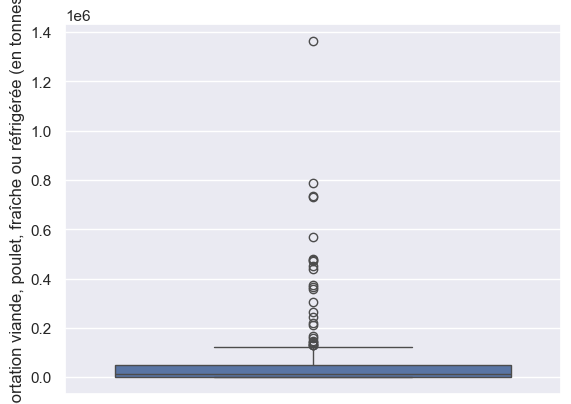

In [104]:
sns.boxplot(data=import_2017, y='Importation viande, poulet, fraîche ou réfrigérée (en tonnes)')
plt.show()

In [105]:
import_2017.count()

Pays                                                             194
Année                                                            194
Importation viande, poulet, fraîche ou réfrigérée (en tonnes)    194
dtype: int64

In [106]:
# Vérification des pays sur le référentiel
import_2017[~import_2017['Pays'].isin(ref_pays['Pays'])]

,Pays,Année,"Importation viande, poulet, fraîche ou réfrigérée (en tonnes)"
35,Chine,2017,1362583.46
136,Pays-Bas (Royaume des),2017,358733.38
183,Türkiye,2017,2752.28


In [107]:
# Changer ces 3 pays
liste = {
    'Pays-Bas (Royaume des)' : 'Pays-Bas',
    'Türkiye' : 'Turquie'
}
import_2017 = import_2017.replace(liste)
import_2017[~import_2017['Pays'].isin(ref_pays['Pays'])]

,Pays,Année,"Importation viande, poulet, fraîche ou réfrigérée (en tonnes)"
35,Chine,2017,1362583.46


In [108]:
# Suppression de la Chine (Chine continentale déjà présent)
import_2017 = import_2017.drop(import_2017[import_2017['Pays']=='Chine'].index)

### Importation en % 

In [109]:
pourcent_import_nourriture.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MAC,WB_WDI_TM_VAL_FOOD_ZS_UN,_T,_T,_T,PT,...,16.042365,16.777520,17.859710,16.396837,16.598367,14.184742,11.050830,15.316286,18.192496,18.467704
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,CHE,WB_WDI_TM_VAL_FOOD_ZS_UN,_T,_T,_T,PT,...,4.575567,4.277333,4.545402,4.539531,4.487405,4.606739,4.635329,4.204870,4.261831,4.731094
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,GNB,WB_WDI_TM_VAL_FOOD_ZS_UN,_T,_T,_T,PT,...,50.452537,46.113032,46.019488,41.710352,NaN,NaN,NaN,NaN,NaN,NaN
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VUT,WB_WDI_TM_VAL_FOOD_ZS_UN,_T,_T,_T,PT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,CEB,WB_WDI_TM_VAL_FOOD_ZS_UN,_T,_T,_T,PT,...,7.882831,8.229581,8.015998,7.643047,8.005804,8.669912,7.774819,7.780491,8.764036,9.149367


In [110]:
for col in pourcent_import_nourriture:
    print(col)

STRUCTURE
STRUCTURE_ID
ACTION
FREQ
REF_AREA
INDICATOR
SEX
AGE
URBANISATION
UNIT_MEASURE
COMP_BREAKDOWN_1
COMP_BREAKDOWN_2
COMP_BREAKDOWN_3
AGG_METHOD
UNIT_TYPE
DECIMALS
DATABASE_ID
TIME_FORMAT
COMMENT_TS
UNIT_MULT
DATA_SOURCE
OBS_CONF
OBS_STATUS
FREQ_LABEL
REF_AREA_LABEL
INDICATOR_LABEL
SEX_LABEL
AGE_LABEL
URBANISATION_LABEL
UNIT_MEASURE_LABEL
COMP_BREAKDOWN_1_LABEL
COMP_BREAKDOWN_2_LABEL
COMP_BREAKDOWN_3_LABEL
AGG_METHOD_LABEL
UNIT_TYPE_LABEL
DECIMALS_LABEL
DATABASE_ID_LABEL
TIME_FORMAT_LABEL
UNIT_MULT_LABEL
OBS_STATUS_LABEL
OBS_CONF_LABEL
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024


In [111]:
pourcent_import_nourriture['UNIT_MEASURE'].unique()

array(['PT'], dtype=object)

In [112]:
# Conserver REF_AREA et 2017
pourcent_import_nourriture_2017 = pourcent_import_nourriture[['REF_AREA', '2017']]
pourcent_import_nourriture_2017.head()

,REF_AREA,2017
0,MAC,17.859710
1,CHE,4.545402
2,GNB,46.019488
3,VUT,NaN
4,CEB,8.015998


In [113]:
# Intégrer les noms des pays
pourcent_import_nourriture_2017 = pourcent_import_nourriture_2017.merge(ref_pays, left_on='REF_AREA', right_on='Code ISO3', how='left')
pourcent_import_nourriture_2017.head()

,REF_AREA,2017,Pays,Code ISO3
0,MAC,17.859710,Chine - RAS de Macao,MAC
1,CHE,4.545402,Suisse,CHE
2,GNB,46.019488,Guinée-Bissau,GNB
3,VUT,NaN,Vanuatu,VUT
4,CEB,8.015998,NaN,NaN


In [114]:
pourcent_import_nourriture_2017.count()

REF_AREA     246
2017         223
Pays         198
Code ISO3    198
dtype: int64

In [115]:
# Vérification des NaN
pourcent_import_nourriture_2017[pourcent_import_nourriture_2017['2017'].isna()]

,REF_AREA,2017,Pays,Code ISO3
3,VUT,NaN,Vanuatu,VUT
7,SRB,NaN,Serbie,SRB
9,FCS,NaN,NaN,NaN
10,SOM,NaN,Somalie,SOM
11,IRQ,NaN,Iraq,IRQ
19,TKM,NaN,Turkménistan,TKM
22,CYM,NaN,Îles Caïmanes,CYM
54,VEN,NaN,Venezuela (République bolivarienne du),VEN
62,GIN,NaN,Guinée,GIN
70,TUV,NaN,Tuvalu,TUV


In [116]:
pourcent_import_nourriture_2017[pourcent_import_nourriture_2017['Pays'].isna()]

,REF_AREA,2017,Pays,Code ISO3
4,CEB,8.015998,NaN,NaN
9,FCS,NaN,NaN,NaN
20,HPC,17.438392,NaN,NaN
31,MIC,8.586671,NaN,NaN
37,EUU,9.906148,NaN,NaN
40,IDX,16.895707,NaN,NaN
42,MEA,13.463525,NaN,NaN
45,LMC,11.022781,NaN,NaN
46,PST,8.188904,NaN,NaN
59,WLD,8.519389,NaN,NaN


In [117]:
# Supprimer les lignes avec pays = NaN (groupements de region etc...)
pourcent_import_nourriture_2017 = pourcent_import_nourriture_2017.dropna(subset='Pays')
pourcent_import_nourriture_2017.head()

,REF_AREA,2017,Pays,Code ISO3
0,MAC,17.859710,Chine - RAS de Macao,MAC
1,CHE,4.545402,Suisse,CHE
2,GNB,46.019488,Guinée-Bissau,GNB
3,VUT,NaN,Vanuatu,VUT
5,AFG,36.793446,Afghanistan,AFG


In [118]:
# Supprimer les colonnes inutiles
pourcent_import_nourriture_2017 = pourcent_import_nourriture_2017.drop(columns=['REF_AREA', 'Code ISO3'])
pourcent_import_nourriture_2017.head()

,2017,Pays
0,17.859710,Chine - RAS de Macao
1,4.545402,Suisse
2,46.019488,Guinée-Bissau
3,NaN,Vanuatu
5,36.793446,Afghanistan


In [119]:
# Renommer les colonnes
pourcent_import_nourriture_2017 = pourcent_import_nourriture_2017.rename(columns={
    '2017' : 'Importation de nourriture (en %)'})
pourcent_import_nourriture_2017.head()  

,Importation de nourriture (en %),Pays
0,17.859710,Chine - RAS de Macao
1,4.545402,Suisse
2,46.019488,Guinée-Bissau
3,NaN,Vanuatu
5,36.793446,Afghanistan


In [120]:
# Ajouter l'année
pourcent_import_nourriture_2017['Année'] = 2017
pourcent_import_nourriture_2017.head()

,Importation de nourriture (en %),Pays,Année
0,17.859710,Chine - RAS de Macao,2017
1,4.545402,Suisse,2017
2,46.019488,Guinée-Bissau,2017
3,NaN,Vanuatu,2017
5,36.793446,Afghanistan,2017


In [121]:
# 2 chiffres après la virgule
pourcent_import_nourriture_2017['Importation de nourriture (en %)'] = pourcent_import_nourriture_2017['Importation de nourriture (en %)'].round(2)
pourcent_import_nourriture_2017.head()

,Importation de nourriture (en %),Pays,Année
0,17.86,Chine - RAS de Macao,2017
1,4.55,Suisse,2017
2,46.02,Guinée-Bissau,2017
3,NaN,Vanuatu,2017
5,36.79,Afghanistan,2017


In [122]:
pourcent_import_nourriture_2017.count()

Importation de nourriture (en %)    176
Pays                                198
Année                               198
dtype: int64

In [123]:
pourcent_import_nourriture_2017[pourcent_import_nourriture_2017['Importation de nourriture (en %)'].isna()]

,Importation de nourriture (en %),Pays,Année
3,NaN,Vanuatu,2017
7,NaN,Serbie,2017
10,NaN,Somalie,2017
11,NaN,Iraq,2017
19,NaN,Turkménistan,2017
22,NaN,Îles Caïmanes,2017
54,NaN,Venezuela (République bolivarienne du),2017
62,NaN,Guinée,2017
70,NaN,Tuvalu,2017
71,NaN,Djibouti,2017


In [124]:
pourcent_import_nourriture_2017 = pourcent_import_nourriture_2017.dropna(subset='Importation de nourriture (en %)')
pourcent_import_nourriture_2017.count()

Importation de nourriture (en %)    176
Pays                                176
Année                               176
dtype: int64

In [125]:
pourcent_import_nourriture_2017[~pourcent_import_nourriture_2017['Pays'].isin(ref_pays['Pays'])]

,Importation de nourriture (en %),Pays,Année


## Taxes sur importation

In [126]:
# Vue du fichier
taxe_import.head()

,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,UNIT_MEASURE,UNIT_MEASURE_LABEL,DATABASE_ID,DATABASE_ID_LABEL,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,A,Annual,AGO,Angola,WEF_GCIHH_TFDUTY,"Trade tariffs, % duty",PT_DUT,Percentage of duty,WEF_GCIHH,Global Competitiveness Index (GCI) - Historica...,...,NaN,NaN,8.60,8.64,NaN,8.88,9.30,NaN,NaN,NaN
1,A,Annual,AGO,Angola,WEF_GCIHH_TFDUTY,"Trade tariffs, % duty",RANK,Rank,WEF_GCIHH,Global Competitiveness Index (GCI) - Historica...,...,NaN,NaN,93.00,93.00,NaN,97.00,100.00,NaN,NaN,NaN
2,A,Annual,ALB,Albania,WEF_GCIHH_TFDUTY,"Trade tariffs, % duty",PT_DUT,Percentage of duty,WEF_GCIHH,Global Competitiveness Index (GCI) - Historica...,...,5.25,4.03,3.32,3.44,3.15,2.72,2.77,2.4,2.37,2.28
3,A,Annual,ALB,Albania,WEF_GCIHH_TFDUTY,"Trade tariffs, % duty",RANK,Rank,WEF_GCIHH,Global Competitiveness Index (GCI) - Historica...,...,65.00,47.00,44.00,43.00,46.00,39.00,42.00,38.0,39.00,39.00
4,A,Annual,ARE,United Arab Emirates,WEF_GCIHH_TFDUTY,"Trade tariffs, % duty",PT_DUT,Percentage of duty,WEF_GCIHH,Global Competitiveness Index (GCI) - Historica...,...,4.77,4.77,4.37,4.49,4.68,4.55,4.15,4.1,3.97,3.99


In [127]:
list(taxe_import.columns)

['FREQ',
 'FREQ_LABEL',
 'REF_AREA',
 'REF_AREA_LABEL',
 'INDICATOR',
 'INDICATOR_LABEL',
 'UNIT_MEASURE',
 'UNIT_MEASURE_LABEL',
 'DATABASE_ID',
 'DATABASE_ID_LABEL',
 'UNIT_MULT',
 'UNIT_MULT_LABEL',
 'OBS_STATUS',
 'OBS_STATUS_LABEL',
 'OBS_CONF',
 'OBS_CONF_LABEL',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017']

In [128]:
taxe_import.count()

FREQ                  304
FREQ_LABEL            304
REF_AREA              304
REF_AREA_LABEL        304
INDICATOR             304
INDICATOR_LABEL       304
UNIT_MEASURE          304
UNIT_MEASURE_LABEL    304
DATABASE_ID           304
DATABASE_ID_LABEL     304
UNIT_MULT             304
UNIT_MULT_LABEL       304
OBS_STATUS            304
OBS_STATUS_LABEL      304
OBS_CONF              304
OBS_CONF_LABEL        304
2007                  248
2008                  262
2009                  262
2010                  270
2011                  280
2012                  280
2013                  294
2014                  288
2015                  280
2016                  276
2017                  274
dtype: int64

In [129]:
taxe_import['INDICATOR_LABEL'].unique()

array(['Trade tariffs, % duty'], dtype=object)

In [130]:
taxe_import.head(2)

,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,UNIT_MEASURE,UNIT_MEASURE_LABEL,DATABASE_ID,DATABASE_ID_LABEL,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,A,Annual,AGO,Angola,WEF_GCIHH_TFDUTY,"Trade tariffs, % duty",PT_DUT,Percentage of duty,WEF_GCIHH,Global Competitiveness Index (GCI) - Historica...,...,NaN,NaN,8.6,8.64,NaN,8.88,9.3,NaN,NaN,NaN
1,A,Annual,AGO,Angola,WEF_GCIHH_TFDUTY,"Trade tariffs, % duty",RANK,Rank,WEF_GCIHH,Global Competitiveness Index (GCI) - Historica...,...,NaN,NaN,93.0,93.00,NaN,97.00,100.0,NaN,NaN,NaN


In [131]:
# Conserver les lignes avec le % de droits de douanes (supprimer les RANK) et les variables REF_AREA, INDICATOR_LABEL, 2017
taxe_import_2017 = taxe_import[taxe_import['UNIT_MEASURE']=='PT_DUT'][['REF_AREA', 'INDICATOR_LABEL', '2017']]
taxe_import_2017.head()

,REF_AREA,INDICATOR_LABEL,2017
0,AGO,"Trade tariffs, % duty",NaN
2,ALB,"Trade tariffs, % duty",2.28
4,ARE,"Trade tariffs, % duty",3.99
6,ARG,"Trade tariffs, % duty",11.66
8,ARM,"Trade tariffs, % duty",3.96


In [132]:
taxe_import_2017.count()

REF_AREA           152
INDICATOR_LABEL    152
2017               137
dtype: int64

In [133]:
taxe_import_2017['2017'].describe()

count    137.000000
mean       6.288759
std        5.070364
min        0.000000
25%        1.850000
50%        4.910000
75%       10.250000
max       29.500000
Name: 2017, dtype: float64

In [134]:
# Intégrer les noms des pays
taxe_import_2017 = taxe_import_2017.merge(ref_pays, left_on='REF_AREA', right_on='Code ISO3', how='left')
taxe_import_2017.head()

,REF_AREA,INDICATOR_LABEL,2017,Pays,Code ISO3
0,AGO,"Trade tariffs, % duty",NaN,Angola,AGO
1,ALB,"Trade tariffs, % duty",2.28,Albanie,ALB
2,ARE,"Trade tariffs, % duty",3.99,Émirats arabes unis,ARE
3,ARG,"Trade tariffs, % duty",11.66,Argentine,ARG
4,ARM,"Trade tariffs, % duty",3.96,Arménie,ARM


In [135]:
# Vérification des NaN
taxe_import_2017[taxe_import_2017['2017'].isna()]

,REF_AREA,INDICATOR_LABEL,2017,Pays,Code ISO3
0,AGO,"Trade tariffs, % duty",NaN,Angola,AGO
11,BFA,"Trade tariffs, % duty",NaN,Burkina Faso,BFA
16,BLZ,"Trade tariffs, % duty",NaN,Belize,BLZ
17,BOL,"Trade tariffs, % duty",NaN,Bolivie (État plurinational de),BOL
19,BRB,"Trade tariffs, % duty",NaN,Barbade,BRB
27,CIV,"Trade tariffs, % duty",NaN,Côte d'Ivoire,CIV
46,GAB,"Trade tariffs, % duty",NaN,Gabon,GAB
54,GUY,"Trade tariffs, % duty",NaN,Guyana,GUY
79,LBY,"Trade tariffs, % duty",NaN,Libye,LBY
89,MKD,"Trade tariffs, % duty",NaN,Macédoine du Nord,MKD


In [136]:
# Effacer ces lignes
taxe_import_2017 = taxe_import_2017.dropna(subset='2017')
taxe_import_2017[taxe_import_2017['2017'].isna()]

,REF_AREA,INDICATOR_LABEL,2017,Pays,Code ISO3


In [137]:
# Renommer la colonne 2017 et ajouter l'année
taxe_import_2017 = taxe_import_2017.rename(columns={'2017' : 'Trade tariffs, % duty'})
taxe_import_2017['Année'] = 2017
taxe_import_2017.head()                                           

,REF_AREA,INDICATOR_LABEL,"Trade tariffs, % duty",Pays,Code ISO3,Année
1,ALB,"Trade tariffs, % duty",2.28,Albanie,ALB,2017
2,ARE,"Trade tariffs, % duty",3.99,Émirats arabes unis,ARE,2017
3,ARG,"Trade tariffs, % duty",11.66,Argentine,ARG,2017
4,ARM,"Trade tariffs, % duty",3.96,Arménie,ARM,2017
5,AUS,"Trade tariffs, % duty",2.16,Australie,AUS,2017


In [138]:
# Supprimer les colonnes inutiles
taxe_import_2017 = taxe_import_2017.drop(columns={'REF_AREA', 'INDICATOR_LABEL', 'Code ISO3'})
taxe_import_2017.head()

,"Trade tariffs, % duty",Pays,Année
1,2.28,Albanie,2017
2,3.99,Émirats arabes unis,2017
3,11.66,Argentine,2017
4,3.96,Arménie,2017
5,2.16,Australie,2017


In [139]:
taxe_import_2017.count()

Trade tariffs, % duty    137
Pays                     137
Année                    137
dtype: int64

In [140]:
# Vérification sur le référentiel pays
taxe_import_2017[~taxe_import_2017['Pays'].isin(ref_pays['Pays'])]

,"Trade tariffs, % duty",Pays,Année


## Indice quantité importation 

In [141]:
# Vue du fichier
indice_quantite_import_2017.head()

,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit (CPC),Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,TI,Indices commerciaux,4,Afghanistan,465,Indice de quantité d'importation (2014-2016 = ...,21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,NaN,72,E,Valeur estimée
1,TI,Indices commerciaux,710,Afrique du Sud,465,Indice de quantité d'importation (2014-2016 = ...,21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,NaN,128,E,Valeur estimée
2,TI,Indices commerciaux,8,Albanie,465,Indice de quantité d'importation (2014-2016 = ...,21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,NaN,85,E,Valeur estimée
3,TI,Indices commerciaux,12,Algérie,465,Indice de quantité d'importation (2014-2016 = ...,21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,NaN,129,E,Valeur estimée
4,TI,Indices commerciaux,276,Allemagne,465,Indice de quantité d'importation (2014-2016 = ...,21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,NaN,112,E,Valeur estimée


In [142]:
indice_quantite_import_2017['Élément'].unique()

array(["Indice de quantité d'importation (2014-2016 = 100)"], dtype=object)

In [143]:
indice_quantite_import_2017.count()

Code Domaine              197
Domaine                   197
Code zone (M49)           197
Zone                      197
Code Élément              197
Élément                   197
Code Produit (CPC)        197
Produit                   197
Code année                197
Année                     197
Unité                       0
Valeur                    197
Symbole                   197
Description du Symbole    197
dtype: int64

In [144]:
indice_quantite_import_2017.duplicated().sum()

np.int64(0)

In [145]:
# Conserver les variables Zone, Année, Valeur
indice_quantite_import_2017 = indice_quantite_import_2017[['Zone', 'Année', 'Valeur']]
indice_quantite_import_2017.head()

,Zone,Année,Valeur
0,Afghanistan,2017,72
1,Afrique du Sud,2017,128
2,Albanie,2017,85
3,Algérie,2017,129
4,Allemagne,2017,112


In [146]:
# Calcul de l'évolution en %
indice_quantite_import_2017['Valeur'] = (indice_quantite_import_2017['Valeur'] - 100)
indice_quantite_import_2017.head()

,Zone,Année,Valeur
0,Afghanistan,2017,-28
1,Afrique du Sud,2017,28
2,Albanie,2017,-15
3,Algérie,2017,29
4,Allemagne,2017,12


In [147]:
# Renommer la colonne Valeur en 'Evolution de l'importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)' et Zone en Pays
indice_quantite_import_2017 = indice_quantite_import_2017.rename(
    columns={'Valeur' : 'Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)', 'Zone' : 'Pays'})
indice_quantite_import_2017.head()

,Pays,Année,"Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)"
0,Afghanistan,2017,-28
1,Afrique du Sud,2017,28
2,Albanie,2017,-15
3,Algérie,2017,29
4,Allemagne,2017,12


In [148]:
indice_quantite_import_2017.count()

Pays                                                                                   197
Année                                                                                  197
Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)    197
dtype: int64

In [149]:
# Vérification des pays sur le référentiel
indice_quantite_import_2017[~indice_quantite_import_2017['Pays'].isin(ref_pays['Pays'])]

,Pays,Année,"Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)"
139,Pays-Bas (Royaume des),2017,23
186,Türkiye,2017,458


In [150]:
# Changer ces 2 pays
liste = {
    'Pays-Bas (Royaume des)' : 'Pays-Bas',
    'Türkiye' : 'Turquie'
}
indice_quantite_import_2017 = indice_quantite_import_2017.replace(liste)

In [151]:
indice_quantite_import_2017[~indice_quantite_import_2017['Pays'].isin(ref_pays['Pays'])]

,Pays,Année,"Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)"


## ESG (Environnement, Social & Gouvernance)

In [152]:
esg.head()

,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,AGE,AGE_LABEL,UNIT_MEASURE,UNIT_MEASURE_LABEL,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,A,Annual,AFG,Afghanistan,WB_ESG_AG_LND_AGRI_ZS,Agricultural land (% of land area),_T,All age ranges or no breakdown by age,PT_LAND_AREA,Percentage of land area,...,58.123668,58.123668,58.123668,58.123668,58.276988,58.276988,58.741548,58.741548,58.741548,NaN
1,A,Annual,AFG,Afghanistan,WB_ESG_AG_LND_FRLS_HA,Tree Cover Loss (hectares),_T,All age ranges or no breakdown by age,HA,Hectares,...,3.000000,0.000000,0.000000,0.000000,26.000000,17.000000,37.000000,26.000000,NaN,NaN
2,A,Annual,AFG,Afghanistan,WB_ESG_AG_LND_FRST_ZS,Forest area (% of land area),_T,All age ranges or no breakdown by age,PT_LAND_AREA,Percentage of land area,...,1.852782,1.852782,1.852782,1.852782,1.852782,1.852782,1.852782,1.852782,1.852782,NaN
3,A,Annual,AFG,Afghanistan,WB_ESG_AG_PRD_FOOD_XD,Food production index (2014-2016 = 100),_T,All age ranges or no breakdown by age,IX_1T100,Score 1-100,...,101.990000,95.970000,102.040000,99.840000,96.190000,109.410000,112.300000,114.320000,111.430000,NaN
4,A,Annual,AFG,Afghanistan,WB_ESG_CC_EST,Control of Corruption: Estimate,_T,All age ranges or no breakdown by age,IX,Index,...,-1.364934,-1.354713,-1.540228,-1.530075,-1.502876,-1.419310,-1.493361,-1.152266,-1.183684,-1.154932


In [153]:
list(esg.columns)

['FREQ',
 'FREQ_LABEL',
 'REF_AREA',
 'REF_AREA_LABEL',
 'INDICATOR',
 'INDICATOR_LABEL',
 'AGE',
 'AGE_LABEL',
 'UNIT_MEASURE',
 'UNIT_MEASURE_LABEL',
 'COMP_BREAKDOWN_1',
 'COMP_BREAKDOWN_1_LABEL',
 'DATABASE_ID',
 'DATABASE_ID_LABEL',
 'UNIT_MULT',
 'UNIT_MULT_LABEL',
 'OBS_STATUS',
 'OBS_STATUS_LABEL',
 'OBS_CONF',
 'OBS_CONF_LABEL',
 '1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023']

In [154]:
# Conserver les variables REF_AREA_LABEL, INDICATOR_LABEL, UNIT_MEASURE_LABEL, 2017

esg_2017 = esg[['REF_AREA', 'INDICATOR_LABEL', 'UNIT_MEASURE', '2017']]
esg_2017.head()

,REF_AREA,INDICATOR_LABEL,UNIT_MEASURE,2017
0,AFG,Agricultural land (% of land area),PT_LAND_AREA,58.123668
1,AFG,Tree Cover Loss (hectares),HA,0.000000
2,AFG,Forest area (% of land area),PT_LAND_AREA,1.852782
3,AFG,Food production index (2014-2016 = 100),IX_1T100,99.840000
4,AFG,Control of Corruption: Estimate,IX,-1.530075


In [155]:
esg_2017['INDICATOR_LABEL'].unique()

array(['Agricultural land (% of land area)', 'Tree Cover Loss (hectares)',
       'Forest area (% of land area)',
       'Food production index (2014-2016 = 100)',
       'Control of Corruption: Estimate',
       'Access to clean fuels and technologies for cooking (% of population)',
       'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
       'Access to electricity (% of population)',
       'Electricity production from coal sources (% of total)',
       'Renewable electricity output (% of total electricity output)',
       'Renewable energy consumption (% of total final energy consumption)',
       'CO2 emissions (metric tons per capita)',
       'Methane emissions (metric tons of CO2 equivalent per capita)',
       'Nitrous oxide emissions (metric tons of CO2 equivalent per capita)',
       'PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)',
       'Cooling Degree Days', 'Heating Degree Days', 'Heat Index 35',
       'Standardised Precipitation-

In [156]:
# Conserver les indicateurs suivants :
# 'Political Stability and Absence of Violence/Terrorism: Estimate' => Stabilité du pays
# 'Government Effectiveness: Estimate' => Qualité des services publics, capacité du gouvernement à appllqué sa politique
# 'Rule of Law: Estimate' => 'Respect des lois'
# 'Regulatory Quality: Estimate' => Capacité du gouvernement à créer des règles favorables au commerce
# 'Control of Corruption: Estimate' => Niveau de corruption
# 'GDP growth (annual %)' => Croissance économique
# 'Population density (people per sq. km of land area)' => Densité de population
# 'Population ages 65 and above (% of total population)' => Age de la populaiton
# 'Prevalence of undernourishment (% of population)' => % de sous nutrition
# 'CO2 emissions (metric tons per capita)' => Emission de CO2 par habitant

liste = ['Political Stability and Absence of Violence/Terrorism: Estimate', 'Government Effectiveness: Estimate', 
         'Rule of Law: Estimate', 'Regulatory Quality: Estimate', 'Control of Corruption: Estimate', 'GDP growth (annual %)',
         'Population density (people per sq. km of land area)', 'Population ages 65 and above (% of total population)',
         'Prevalence of undernourishment (% of population)', 'CO2 emissions (metric tons per capita)']

In [157]:
esg_2017 = esg_2017[esg_2017['INDICATOR_LABEL'].isin(liste)]
esg_2017.head()

,REF_AREA,INDICATOR_LABEL,UNIT_MEASURE,2017
4,AFG,Control of Corruption: Estimate,IX,-1.530075
11,AFG,CO2 emissions (metric tons per capita),T_POP,0.280837
21,AFG,Population density (people per sq. km of land ...,POP_KM2_LA,54.718328
25,AFG,Government Effectiveness: Estimate,IX,-1.386597
32,AFG,GDP growth (annual %),PT_YR,2.647003


In [158]:
esg_2017['UNIT_MEASURE'].unique()

array(['IX', 'T_POP', 'POP_KM2_LA', 'PT_YR', 'PT_TOT'], dtype=object)

In [159]:
# IX = Index
# T_POP = Tonnes par habitants
# POP_KM2_LA = Popullation par km²
# PT_YR = % par an
# PT_TOT = % sur le total

In [160]:
# Pivoter la table
esg_2017 = esg_2017.pivot_table(index='REF_AREA', values='2017', columns=['INDICATOR_LABEL', 'UNIT_MEASURE'])
esg_2017.head()

INDICATOR_LABEL,CO2 emissions (metric tons per capita),Control of Corruption: Estimate,GDP growth (annual %),Government Effectiveness: Estimate,Political Stability and Absence of Violence/Terrorism: Estimate,Population ages 65 and above (% of total population),Population density (people per sq. km of land area),Prevalence of undernourishment (% of population),Regulatory Quality: Estimate,Rule of Law: Estimate
UNIT_MEASURE,T_POP,IX,PT_YR,IX,IX,PT_TOT,POP_KM2_LA,PT_TOT,IX,IX
REF_AREA,,,,,,,,,,
AFG,0.280837,-1.530075,2.647003,-1.386597,-2.794976,2.359737,54.718328,21.400000,-1.363010,-1.581176
AGO,0.829004,-1.445172,-0.147213,-0.951989,-0.387895,2.685242,24.251896,15.200000,-1.045467,-1.039982
ALB,1.880557,-0.481387,3.283176,0.098553,0.373771,13.305391,104.870693,4.300000,0.220610,-0.414192
AND,6.308420,1.171781,0.346072,1.876946,1.392890,13.198441,156.942553,NaN,1.200185,1.535569
ARB,4.303440,NaN,1.604826,NaN,NaN,3.980062,32.694546,12.209306,NaN,NaN


In [161]:
esg_2017 = esg_2017.rename(columns={'CO2 emissions (metric tons per capita)' : 'Emissions CO2 (tonnes par habitant)',
                                    'Control of Corruption: Estimate' : 'Index de corruption (estimé)',
                                    'GDP growth (annual %)' : 'Croissance annuelle (en %)',
                                    'Government Effectiveness: Estimate' : 'Index efficacité gouvernementale',
                                    'Political Stability and Absence of Violence/Terrorism: Estimate' : 'Stabilité politique et violence/terrorisme (index)',
                                    'Population ages 65 and above (% of total population)' : '% de la population agé de 65 ans et +',
                                    'Population density (people per sq. km of land area)' : 'Densité habitant au km2',
                                    'Prevalence of undernourishment (% of population)' : '% de sous nutrition',
                                    'Regulatory Quality: Estimate' : 'Index de facilité pour le commerce',
                                    'Rule of Law: Estimate' : 'Index de respect des lois',
                                   })
esg_2017.head()

INDICATOR_LABEL,Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,Stabilité politique et violence/terrorisme (index),% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
UNIT_MEASURE,T_POP,IX,PT_YR,IX,IX,PT_TOT,POP_KM2_LA,PT_TOT,IX,IX
REF_AREA,,,,,,,,,,
AFG,0.280837,-1.530075,2.647003,-1.386597,-2.794976,2.359737,54.718328,21.400000,-1.363010,-1.581176
AGO,0.829004,-1.445172,-0.147213,-0.951989,-0.387895,2.685242,24.251896,15.200000,-1.045467,-1.039982
ALB,1.880557,-0.481387,3.283176,0.098553,0.373771,13.305391,104.870693,4.300000,0.220610,-0.414192
AND,6.308420,1.171781,0.346072,1.876946,1.392890,13.198441,156.942553,NaN,1.200185,1.535569
ARB,4.303440,NaN,1.604826,NaN,NaN,3.980062,32.694546,12.209306,NaN,NaN


In [162]:
esg_2017.columns = esg_2017.columns.get_level_values(0)
esg_2017.head()

INDICATOR_LABEL,Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,Stabilité politique et violence/terrorisme (index),% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
REF_AREA,,,,,,,,,,
AFG,0.280837,-1.530075,2.647003,-1.386597,-2.794976,2.359737,54.718328,21.400000,-1.363010,-1.581176
AGO,0.829004,-1.445172,-0.147213,-0.951989,-0.387895,2.685242,24.251896,15.200000,-1.045467,-1.039982
ALB,1.880557,-0.481387,3.283176,0.098553,0.373771,13.305391,104.870693,4.300000,0.220610,-0.414192
AND,6.308420,1.171781,0.346072,1.876946,1.392890,13.198441,156.942553,NaN,1.200185,1.535569
ARB,4.303440,NaN,1.604826,NaN,NaN,3.980062,32.694546,12.209306,NaN,NaN


In [163]:
esg_2017.columns.name=None
esg_2017.head()

,Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,Stabilité politique et violence/terrorisme (index),% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
REF_AREA,,,,,,,,,,
AFG,0.280837,-1.530075,2.647003,-1.386597,-2.794976,2.359737,54.718328,21.400000,-1.363010,-1.581176
AGO,0.829004,-1.445172,-0.147213,-0.951989,-0.387895,2.685242,24.251896,15.200000,-1.045467,-1.039982
ALB,1.880557,-0.481387,3.283176,0.098553,0.373771,13.305391,104.870693,4.300000,0.220610,-0.414192
AND,6.308420,1.171781,0.346072,1.876946,1.392890,13.198441,156.942553,NaN,1.200185,1.535569
ARB,4.303440,NaN,1.604826,NaN,NaN,3.980062,32.694546,12.209306,NaN,NaN


In [164]:
esg_2017.describe()

,Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,Stabilité politique et violence/terrorisme (index),% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
count,237.000000,193.000000,234.000000,193.000000,193.000000,239.000000,239.000000,213.000000,193.000000,193.000000
mean,4.107300,-0.078583,3.444974,-0.075810,-0.074114,8.589887,251.819270,9.820992,-0.082189,-0.080874
std,4.605903,0.995529,3.529260,0.994992,0.987379,6.206307,1311.671129,9.827541,0.988482,0.989149
min,0.032670,-1.748293,-7.544364,-2.440221,-2.934317,1.122525,2.022094,2.500000,-2.368034,-2.331677
25%,0.809457,-0.787501,1.874440,-0.751180,-0.651365,3.571896,35.512841,2.500000,-0.790258,-0.792975
50%,2.674347,-0.291626,3.347536,-0.174113,0.022408,6.140136,73.890288,6.106898,-0.162279,-0.201814
75%,5.756134,0.634742,5.097702,0.535492,0.749313,13.074393,148.312038,13.200000,0.479722,0.557143
max,34.359106,2.195915,32.491802,2.225982,1.615091,35.577791,18588.061174,58.300000,2.109155,2.024068


In [165]:
esg_2017[esg_2017['Densité habitant au km2']== esg_2017['Densité habitant au km2'].max()]

,Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,Stabilité politique et violence/terrorisme (index),% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
REF_AREA,,,,,,,,,,
MCO,NaN,1.762287,-3.206183,1.876946,1.615091,35.577791,18588.061174,NaN,1.200185,1.535569


In [166]:
# Jointure pour avoir les pays
esg_2017 = esg_2017.merge(ref_pays, left_on='REF_AREA', right_on='Code ISO3', how='left')
esg_2017.head()

,Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,Stabilité politique et violence/terrorisme (index),% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois,Pays,Code ISO3
0,0.280837,-1.530075,2.647003,-1.386597,-2.794976,2.359737,54.718328,21.400000,-1.363010,-1.581176,Afghanistan,AFG
1,0.829004,-1.445172,-0.147213,-0.951989,-0.387895,2.685242,24.251896,15.200000,-1.045467,-1.039982,Angola,AGO
2,1.880557,-0.481387,3.283176,0.098553,0.373771,13.305391,104.870693,4.300000,0.220610,-0.414192,Albanie,ALB
3,6.308420,1.171781,0.346072,1.876946,1.392890,13.198441,156.942553,NaN,1.200185,1.535569,Andorre,AND
4,4.303440,NaN,1.604826,NaN,NaN,3.980062,32.694546,12.209306,NaN,NaN,NaN,NaN


In [167]:
esg_2017[esg_2017['Pays'].isna()]

,Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,Stabilité politique et violence/terrorisme (index),% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois,Pays,Code ISO3
4,4.303440,NaN,1.604826,NaN,NaN,3.980062,32.694546,12.209306,NaN,NaN,NaN,NaN
31,6.684581,NaN,5.107008,NaN,NaN,17.845820,92.604734,2.644873,NaN,NaN,NaN,NaN
43,6.662246,NaN,-0.787702,NaN,NaN,8.103052,10.955678,6.084218,NaN,NaN,NaN,NaN
53,5.561375,NaN,6.666691,NaN,NaN,9.506277,130.567655,4.299646,NaN,NaN,NaN,NaN
54,2.202609,NaN,4.648945,NaN,NaN,5.544759,98.275593,9.887546,NaN,NaN,NaN,NaN
55,5.943876,NaN,5.049622,NaN,NaN,10.744656,95.364092,4.144328,NaN,NaN,NaN,NaN
56,4.884394,NaN,5.819172,NaN,NaN,9.620177,41.369505,3.075900,NaN,NaN,NaN,NaN
57,6.737294,NaN,2.873175,NaN,NaN,16.032040,33.350953,2.669369,NaN,NaN,NaN,NaN
60,6.603432,NaN,2.597495,NaN,NaN,20.297371,126.028701,2.525239,NaN,NaN,NaN,NaN
65,6.584341,NaN,2.794143,NaN,NaN,19.786874,111.425641,2.533293,NaN,NaN,NaN,NaN


In [168]:
# Suppression de ces lignes
esg_2017 = esg_2017.dropna(subset='Pays')
esg_2017.head()

,Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,Stabilité politique et violence/terrorisme (index),% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois,Pays,Code ISO3
0,0.280837,-1.530075,2.647003,-1.386597,-2.794976,2.359737,54.718328,21.4,-1.363010,-1.581176,Afghanistan,AFG
1,0.829004,-1.445172,-0.147213,-0.951989,-0.387895,2.685242,24.251896,15.2,-1.045467,-1.039982,Angola,AGO
2,1.880557,-0.481387,3.283176,0.098553,0.373771,13.305391,104.870693,4.3,0.220610,-0.414192,Albanie,ALB
3,6.308420,1.171781,0.346072,1.876946,1.392890,13.198441,156.942553,NaN,1.200185,1.535569,Andorre,AND
5,20.809966,1.095754,0.735069,1.408903,0.601950,1.478884,129.867995,4.2,1.000955,0.768335,Émirats arabes unis,ARE


In [169]:
# Suppression des colonnes inutiles et ajout de l'année
esg_2017['Année'] = 2017
esg_2017 = esg_2017.drop(columns='Code ISO3')
esg_2017.head()

,Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,Stabilité politique et violence/terrorisme (index),% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois,Pays,Année
0,0.280837,-1.530075,2.647003,-1.386597,-2.794976,2.359737,54.718328,21.4,-1.363010,-1.581176,Afghanistan,2017
1,0.829004,-1.445172,-0.147213,-0.951989,-0.387895,2.685242,24.251896,15.2,-1.045467,-1.039982,Angola,2017
2,1.880557,-0.481387,3.283176,0.098553,0.373771,13.305391,104.870693,4.3,0.220610,-0.414192,Albanie,2017
3,6.308420,1.171781,0.346072,1.876946,1.392890,13.198441,156.942553,NaN,1.200185,1.535569,Andorre,2017
5,20.809966,1.095754,0.735069,1.408903,0.601950,1.478884,129.867995,4.2,1.000955,0.768335,Émirats arabes unis,2017


In [170]:
esg_2017.count()

Emissions CO2 (tonnes par habitant)                   191
Index de corruption (estimé)                          193
Croissance annuelle (en %)                            188
Index efficacité gouvernementale                      193
Stabilité politique et violence/terrorisme (index)    193
% de la population agé de 65 ans et +                 193
Densité habitant au km2                               193
% de sous nutrition                                   167
Index de facilité pour le commerce                    193
Index de respect des lois                             193
Pays                                                  193
Année                                                 193
dtype: int64

In [171]:
# Vérification sur le référentiel pays
esg_2017[~esg_2017['Pays'].isin(ref_pays['Pays'])]

,Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,Stabilité politique et violence/terrorisme (index),% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois,Pays,Année


# Jointure

In [172]:
# Dispo_alimentaire et population
joint_1 = dispo_alimentaire_2017.merge(population_2017, on=['Pays', 'Année'], how='outer')
joint_1.head()

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes","Importations - Quantité (viande de volailles, en milliers de tonnes","Production (viande de volailles, en milliers de tonnes)",Population totale
0,Afghanistan,2017,57.0,NaN,29.0,28.0,36296113.0
1,Afrique du Sud,2017,2118.0,63.0,514.0,1667.0,57009756.0
2,Albanie,2017,47.0,0.0,38.0,13.0,2884169.0
3,Algérie,2017,277.0,0.0,2.0,275.0,41389189.0
4,Allemagne,2017,1739.0,646.0,842.0,1514.0,82658409.0


In [173]:
joint_1.count()

Pays                                                                   236
Année                                                                  236
Disponibiité intérieur (viande de volailles, en milliers de tonnes     170
Exportations - Quantité (viande volailles, en milliers de tonnes       135
Importations - Quantité (viande de volailles, en milliers de tonnes    170
Production (viande de volailles, en milliers de tonnes)                168
Population totale                                                      236
dtype: int64

In [174]:
# joint1 (population/dispo_alim) & stabilité politique
joint_2 = joint_1.merge(stabilite_politique_2017, on=['Pays', 'Année'], how='outer')
joint_2.head()

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes","Importations - Quantité (viande de volailles, en milliers de tonnes","Production (viande de volailles, en milliers de tonnes)",Population totale,Stabilité politique
0,Afghanistan,2017,57.0,NaN,29.0,28.0,36296113.0,-2.794976
1,Afrique du Sud,2017,2118.0,63.0,514.0,1667.0,57009756.0,-0.284804
2,Albanie,2017,47.0,0.0,38.0,13.0,2884169.0,0.373771
3,Algérie,2017,277.0,0.0,2.0,275.0,41389189.0,-0.919614
4,Allemagne,2017,1739.0,646.0,842.0,1514.0,82658409.0,0.574381


In [175]:
joint_2.count()

Pays                                                                   236
Année                                                                  236
Disponibiité intérieur (viande de volailles, en milliers de tonnes     170
Exportations - Quantité (viande volailles, en milliers de tonnes       135
Importations - Quantité (viande de volailles, en milliers de tonnes    170
Production (viande de volailles, en milliers de tonnes)                168
Population totale                                                      236
Stabilité politique                                                    204
dtype: int64

In [176]:
# joint_2 & pouvoir_achat
joint_3 = joint_2.merge(pouvoir_achat_2017, on=['Pays', 'Année'], how='outer')
joint_3.head()

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes","Importations - Quantité (viande de volailles, en milliers de tonnes","Production (viande de volailles, en milliers de tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD)
0,Afghanistan,2017,57.0,NaN,29.0,28.0,36296113.0,-2.794976,525.469771
1,Afrique du Sud,2017,2118.0,63.0,514.0,1667.0,57009756.0,-0.284804,6618.335083
2,Albanie,2017,47.0,0.0,38.0,13.0,2884169.0,0.373771,5006.360130
3,Algérie,2017,277.0,0.0,2.0,275.0,41389189.0,-0.919614,4554.667540
4,Allemagne,2017,1739.0,646.0,842.0,1514.0,82658409.0,0.574381,45553.934150


In [177]:
joint_3.count()

Pays                                                                   237
Année                                                                  237
Disponibiité intérieur (viande de volailles, en milliers de tonnes     170
Exportations - Quantité (viande volailles, en milliers de tonnes       135
Importations - Quantité (viande de volailles, en milliers de tonnes    170
Production (viande de volailles, en milliers de tonnes)                168
Population totale                                                      236
Stabilité politique                                                    204
PIB par habitant (en USD)                                              209
dtype: int64

In [178]:
inflation_2017.head()

,Pays,Année,Food price inflation (en %)
0,Afghanistan,2017,6.957529
1,Afrique du Sud,2017,6.902635
2,Albanie,2017,3.913865
3,Algérie,2017,5.040496
4,Allemagne,2017,2.762495


In [179]:
# Joint_3 & inflation
joint_4 = joint_3.merge(inflation_2017, on=['Pays', 'Année'], how='outer')
joint_4.head()

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes","Importations - Quantité (viande de volailles, en milliers de tonnes","Production (viande de volailles, en milliers de tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %)
0,Afghanistan,2017,57.0,NaN,29.0,28.0,36296113.0,-2.794976,525.469771,6.957529
1,Afrique du Sud,2017,2118.0,63.0,514.0,1667.0,57009756.0,-0.284804,6618.335083,6.902635
2,Albanie,2017,47.0,0.0,38.0,13.0,2884169.0,0.373771,5006.360130,3.913865
3,Algérie,2017,277.0,0.0,2.0,275.0,41389189.0,-0.919614,4554.667540,5.040496
4,Allemagne,2017,1739.0,646.0,842.0,1514.0,82658409.0,0.574381,45553.934150,2.762495


In [180]:
joint_4.count()

Pays                                                                   238
Année                                                                  238
Disponibiité intérieur (viande de volailles, en milliers de tonnes     170
Exportations - Quantité (viande volailles, en milliers de tonnes       135
Importations - Quantité (viande de volailles, en milliers de tonnes    170
Production (viande de volailles, en milliers de tonnes)                168
Population totale                                                      236
Stabilité politique                                                    204
PIB par habitant (en USD)                                              209
Food price inflation (en %)                                            203
dtype: int64

In [181]:
# joint_4 & prod_poulet
joint_5 = joint_4.merge(prod_poulet_2017, on=['Pays', 'Année'], how='outer')
joint_5.head()

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes","Importations - Quantité (viande de volailles, en milliers de tonnes","Production (viande de volailles, en milliers de tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)"
0,Afghanistan,2017,57.0,NaN,29.0,28.0,36296113.0,-2.794976,525.469771,6.957529,27637.84
1,Afrique du Sud,2017,2118.0,63.0,514.0,1667.0,57009756.0,-0.284804,6618.335083,6.902635,1658159.00
2,Albanie,2017,47.0,0.0,38.0,13.0,2884169.0,0.373771,5006.360130,3.913865,12912.00
3,Algérie,2017,277.0,0.0,2.0,275.0,41389189.0,-0.919614,4554.667540,5.040496,364252.17
4,Allemagne,2017,1739.0,646.0,842.0,1514.0,82658409.0,0.574381,45553.934150,2.762495,1009565.00


In [182]:
joint_5.count()

Pays                                                                   238
Année                                                                  238
Disponibiité intérieur (viande de volailles, en milliers de tonnes     170
Exportations - Quantité (viande volailles, en milliers de tonnes       135
Importations - Quantité (viande de volailles, en milliers de tonnes    170
Production (viande de volailles, en milliers de tonnes)                168
Population totale                                                      236
Stabilité politique                                                    204
PIB par habitant (en USD)                                              209
Food price inflation (en %)                                            203
Production viande, poulet, fraîche ou réfrigérée (en tonnes)           194
dtype: int64

In [183]:
# Joint_5 & importation (quantité)
joint_6 = joint_5.merge(import_2017, on=['Pays', 'Année'], how='outer')
joint_6.head()

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes","Importations - Quantité (viande de volailles, en milliers de tonnes","Production (viande de volailles, en milliers de tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)"
0,Afghanistan,2017,57.0,NaN,29.0,28.0,36296113.0,-2.794976,525.469771,6.957529,27637.84,28937.00
1,Afrique du Sud,2017,2118.0,63.0,514.0,1667.0,57009756.0,-0.284804,6618.335083,6.902635,1658159.00,480345.55
2,Albanie,2017,47.0,0.0,38.0,13.0,2884169.0,0.373771,5006.360130,3.913865,12912.00,17515.47
3,Algérie,2017,277.0,0.0,2.0,275.0,41389189.0,-0.919614,4554.667540,5.040496,364252.17,0.40
4,Allemagne,2017,1739.0,646.0,842.0,1514.0,82658409.0,0.574381,45553.934150,2.762495,1009565.00,474950.63


In [184]:
# Joint_6 & import en %
joint_7 = joint_6.merge(pourcent_import_nourriture_2017, on=['Pays', 'Année'], how='inner')
joint_7.head()

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes","Importations - Quantité (viande de volailles, en milliers de tonnes","Production (viande de volailles, en milliers de tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %)
0,Afghanistan,2017,57.0,NaN,29.0,28.0,36296113.0,-2.794976,525.469771,6.957529,27637.84,28937.00,36.79
1,Afrique du Sud,2017,2118.0,63.0,514.0,1667.0,57009756.0,-0.284804,6618.335083,6.902635,1658159.00,480345.55,7.88
2,Albanie,2017,47.0,0.0,38.0,13.0,2884169.0,0.373771,5006.360130,3.913865,12912.00,17515.47,14.86
3,Algérie,2017,277.0,0.0,2.0,275.0,41389189.0,-0.919614,4554.667540,5.040496,364252.17,0.40,20.23
4,Allemagne,2017,1739.0,646.0,842.0,1514.0,82658409.0,0.574381,45553.934150,2.762495,1009565.00,474950.63,8.19


In [185]:
# joint7 & taxes
joint_8 = joint_7.merge(taxe_import_2017, on=['Pays', 'Année'], how='outer')
joint_8.head()

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes","Importations - Quantité (viande de volailles, en milliers de tonnes","Production (viande de volailles, en milliers de tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty"
0,Afghanistan,2017,57.0,NaN,29.0,28.0,36296113.0,-2.794976,525.469771,6.957529,27637.84,28937.00,36.79,NaN
1,Afrique du Sud,2017,2118.0,63.0,514.0,1667.0,57009756.0,-0.284804,6618.335083,6.902635,1658159.00,480345.55,7.88,6.34
2,Albanie,2017,47.0,0.0,38.0,13.0,2884169.0,0.373771,5006.360130,3.913865,12912.00,17515.47,14.86,2.28
3,Algérie,2017,277.0,0.0,2.0,275.0,41389189.0,-0.919614,4554.667540,5.040496,364252.17,0.40,20.23,14.00
4,Allemagne,2017,1739.0,646.0,842.0,1514.0,82658409.0,0.574381,45553.934150,2.762495,1009565.00,474950.63,8.19,1.11


In [186]:
# joint_8 & indices quantité import
joint_9 = joint_8.merge(indice_quantite_import_2017, on=['Pays', 'Année'], how='outer')
joint_9.head()

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes","Importations - Quantité (viande de volailles, en milliers de tonnes","Production (viande de volailles, en milliers de tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)"
0,Afghanistan,2017,57.0,NaN,29.0,28.0,36296113.0,-2.794976,525.469771,6.957529,27637.84,28937.00,36.79,NaN,-28.0
1,Afrique du Sud,2017,2118.0,63.0,514.0,1667.0,57009756.0,-0.284804,6618.335083,6.902635,1658159.00,480345.55,7.88,6.34,28.0
2,Albanie,2017,47.0,0.0,38.0,13.0,2884169.0,0.373771,5006.360130,3.913865,12912.00,17515.47,14.86,2.28,-15.0
3,Algérie,2017,277.0,0.0,2.0,275.0,41389189.0,-0.919614,4554.667540,5.040496,364252.17,0.40,20.23,14.00,29.0
4,Allemagne,2017,1739.0,646.0,842.0,1514.0,82658409.0,0.574381,45553.934150,2.762495,1009565.00,474950.63,8.19,1.11,12.0


In [187]:
# joint_9 & ESG(Environnement, Social & Gouvernance)
market_global = joint_9.merge(esg_2017, on=['Pays', 'Année'], how='outer')

In [188]:
# Voir tous le fichier
pd.set_option('display.max_columns', None)
market_global.head()

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes","Importations - Quantité (viande de volailles, en milliers de tonnes","Production (viande de volailles, en milliers de tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,Stabilité politique et violence/terrorisme (index),% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
0,Afghanistan,2017,57.0,NaN,29.0,28.0,36296113.0,-2.794976,525.469771,6.957529,27637.84,28937.00,36.79,NaN,-28.0,0.280837,-1.530075,2.647003,-1.386597,-2.794976,2.359737,54.718328,21.4,-1.363010,-1.581176
1,Afrique du Sud,2017,2118.0,63.0,514.0,1667.0,57009756.0,-0.284804,6618.335083,6.902635,1658159.00,480345.55,7.88,6.34,28.0,7.551198,-0.127773,1.157947,0.070796,-0.284804,5.628056,47.511035,5.7,0.138878,-0.156248
2,Albanie,2017,47.0,0.0,38.0,13.0,2884169.0,0.373771,5006.360130,3.913865,12912.00,17515.47,14.86,2.28,-15.0,1.880557,-0.481387,3.283176,0.098553,0.373771,13.305391,104.870693,4.3,0.220610,-0.414192
3,Algérie,2017,277.0,0.0,2.0,275.0,41389189.0,-0.919614,4554.667540,5.040496,364252.17,0.40,20.23,14.00,29.0,3.782851,-0.598896,1.500000,-0.537024,-0.919614,5.467242,17.503708,2.5,-1.279499,-0.925013
4,Allemagne,2017,1739.0,646.0,842.0,1514.0,82658409.0,0.574381,45553.934150,2.762495,1009565.00,474950.63,8.19,1.11,12.0,8.858345,1.796976,2.716025,1.613112,0.574381,21.293641,236.588723,2.5,1.775263,1.574070


In [189]:
# Supprimer les redondances => Importation et Production, conserver celles centré sur le poulet
market_global = market_global.drop(columns=['Importations - Quantité (viande de volailles, en milliers de tonnes',
                                                      'Production (viande de volailles, en milliers de tonnes)']
                                            )

In [190]:
market_global.head()

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,Stabilité politique et violence/terrorisme (index),% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
0,Afghanistan,2017,57.0,NaN,36296113.0,-2.794976,525.469771,6.957529,27637.84,28937.00,36.79,NaN,-28.0,0.280837,-1.530075,2.647003,-1.386597,-2.794976,2.359737,54.718328,21.4,-1.363010,-1.581176
1,Afrique du Sud,2017,2118.0,63.0,57009756.0,-0.284804,6618.335083,6.902635,1658159.00,480345.55,7.88,6.34,28.0,7.551198,-0.127773,1.157947,0.070796,-0.284804,5.628056,47.511035,5.7,0.138878,-0.156248
2,Albanie,2017,47.0,0.0,2884169.0,0.373771,5006.360130,3.913865,12912.00,17515.47,14.86,2.28,-15.0,1.880557,-0.481387,3.283176,0.098553,0.373771,13.305391,104.870693,4.3,0.220610,-0.414192
3,Algérie,2017,277.0,0.0,41389189.0,-0.919614,4554.667540,5.040496,364252.17,0.40,20.23,14.00,29.0,3.782851,-0.598896,1.500000,-0.537024,-0.919614,5.467242,17.503708,2.5,-1.279499,-0.925013
4,Allemagne,2017,1739.0,646.0,82658409.0,0.574381,45553.934150,2.762495,1009565.00,474950.63,8.19,1.11,12.0,8.858345,1.796976,2.716025,1.613112,0.574381,21.293641,236.588723,2.5,1.775263,1.574070


# Nettoyage

In [191]:
market_global.shape

(205, 23)

In [192]:
market_global.count()

Pays                                                                                   205
Année                                                                                  205
Disponibiité intérieur (viande de volailles, en milliers de tonnes                     157
Exportations - Quantité (viande volailles, en milliers de tonnes                       128
Population totale                                                                      176
Stabilité politique                                                                    175
PIB par habitant (en USD)                                                              176
Food price inflation (en %)                                                            173
Production viande, poulet, fraîche ou réfrigérée (en tonnes)                           170
Importation viande, poulet, fraîche ou réfrigérée (en tonnes)                          167
Importation de nourriture (en %)                                                       176

In [193]:
# Verification du doublon stabilité politique
stab = market_global[['Pays', 'Stabilité politique', 'Stabilité politique et violence/terrorisme (index)']]
stab

,Pays,Stabilité politique,Stabilité politique et violence/terrorisme (index)
0,Afghanistan,-2.794976,-2.794976
1,Afrique du Sud,-0.284804,-0.284804
2,Albanie,0.373771,0.373771
3,Algérie,-0.919614,-0.919614
4,Allemagne,0.574381,0.574381
...,...,...,...
200,Éthiopie,-1.677231,-1.677231
201,Îles Cook,NaN,NaN
202,Îles Féroé,NaN,NaN
203,Îles Marshall,NaN,1.034588


In [194]:
# Identique suppression de la première
market_global = market_global.drop(columns='Stabilité politique et violence/terrorisme (index)')
market_global.head()

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
0,Afghanistan,2017,57.0,NaN,36296113.0,-2.794976,525.469771,6.957529,27637.84,28937.00,36.79,NaN,-28.0,0.280837,-1.530075,2.647003,-1.386597,2.359737,54.718328,21.4,-1.363010,-1.581176
1,Afrique du Sud,2017,2118.0,63.0,57009756.0,-0.284804,6618.335083,6.902635,1658159.00,480345.55,7.88,6.34,28.0,7.551198,-0.127773,1.157947,0.070796,5.628056,47.511035,5.7,0.138878,-0.156248
2,Albanie,2017,47.0,0.0,2884169.0,0.373771,5006.360130,3.913865,12912.00,17515.47,14.86,2.28,-15.0,1.880557,-0.481387,3.283176,0.098553,13.305391,104.870693,4.3,0.220610,-0.414192
3,Algérie,2017,277.0,0.0,41389189.0,-0.919614,4554.667540,5.040496,364252.17,0.40,20.23,14.00,29.0,3.782851,-0.598896,1.500000,-0.537024,5.467242,17.503708,2.5,-1.279499,-0.925013
4,Allemagne,2017,1739.0,646.0,82658409.0,0.574381,45553.934150,2.762495,1009565.00,474950.63,8.19,1.11,12.0,8.858345,1.796976,2.716025,1.613112,21.293641,236.588723,2.5,1.775263,1.574070


In [195]:
# Vérifier les pays avec beaucoup d'informations manquantes (seuil > 10)
market_global[market_global.isna().sum(axis=1)>10]

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
11,Aruba,2017,NaN,NaN,105366.0,1.313846,28440.041688,-2.958473,NaN,NaN,29.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,Bermudes,2017,NaN,NaN,63049.0,0.981491,112339.425587,2.233201,NaN,NaN,20.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,"Chine, Taiwan Province de",2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.02,-2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,Groenland,2017,NaN,NaN,56481.0,1.927584,50765.749467,2.191969,NaN,NaN,20.81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,Guinée équatoriale,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.0,3.436581,-1.645761,-5.667509,-1.172330,3.342656,55.700392,NaN,-1.575710,-1.368349
97,Liechtenstein,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.103298,1.998276,NaN,1.718035,17.374936,237.262500,NaN,1.485093,1.634370
111,Micronésie (États fédérés de),2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.0,1.339959,0.768537,0.823045,0.397116,4.306207,156.401429,NaN,-0.994520,0.049692
112,Monaco,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.762287,-3.206183,1.876946,35.577791,18588.061174,NaN,1.200185,1.535569
118,Nauru,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,4.945249,0.561709,-6.011230,-0.047564,1.788237,566.200000,NaN,-0.811553,-0.066744
122,Nioué,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-47.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [196]:
# Suppression de ces lignes
market_global = market_global.drop(market_global[market_global.isna().sum(axis=1)>10].index)

In [197]:
market_global.count()

Pays                                                                                   184
Année                                                                                  184
Disponibiité intérieur (viande de volailles, en milliers de tonnes                     156
Exportations - Quantité (viande volailles, en milliers de tonnes                       127
Population totale                                                                      171
Stabilité politique                                                                    171
PIB par habitant (en USD)                                                              171
Food price inflation (en %)                                                            168
Production viande, poulet, fraîche ou réfrigérée (en tonnes)                           168
Importation viande, poulet, fraîche ou réfrigérée (en tonnes)                          165
Importation de nourriture (en %)                                                       171

In [198]:
# Vérification des doublons pays
market_global['Pays'].duplicated().sum()

np.int64(0)

In [199]:
# Vérification des pays avec la population manquante
market_global[market_global['Population totale'].isna()]

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
51,Djibouti,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.0,0.382427,-0.671424,5.458092,-1.086727,4.267233,45.506514,12.7,-0.689585,-0.931998
68,Guinée,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.91,75.0,0.268181,-1.037583,10.300005,-1.085494,3.477704,50.405580,13.2,-0.864647,-1.254245
73,Haïti,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.29,8.0,0.307480,-1.258249,2.510271,-2.128218,4.231095,392.516473,40.6,-1.346591,-1.091791
79,Iraq,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.0,3.977299,-1.431631,-1.819750,-1.222116,3.150723,90.612338,16.6,-1.110490,-1.755345
134,Papouasie-Nouvelle-Guinée,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.0,0.708629,-0.912017,3.534611,-0.664057,2.936533,20.268326,27.3,-0.665424,-0.817371
146,République arabe syrienne,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,1.341734,-1.583552,-0.723282,-1.800828,4.396698,104.692414,17.6,-1.853043,-2.097953
161,Serbie,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.23,-12.0,6.743136,-0.435911,2.363394,0.073256,19.907383,80.275074,2.5,-0.046661,-0.179727
167,Somalie,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.0,0.043904,-1.742241,14.735796,-2.284247,2.461893,23.777583,58.3,-2.284105,-2.331677
176,Tchad,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.24,-45.0,0.095258,-1.455860,-1.627994,-1.509389,2.047494,12.406892,26.6,-1.225706,-1.318427
184,Turkménistan,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-25.0,9.815737,-1.369124,6.500000,-1.011746,3.627298,13.846873,3.4,-1.999273,-1.481559


In [200]:
# Supprimer ces pays
market_global = market_global.drop(market_global[market_global['Population totale'].isna()].index)

In [201]:
market_global.count()

Pays                                                                                   171
Année                                                                                  171
Disponibiité intérieur (viande de volailles, en milliers de tonnes                     156
Exportations - Quantité (viande volailles, en milliers de tonnes                       127
Population totale                                                                      171
Stabilité politique                                                                    171
PIB par habitant (en USD)                                                              171
Food price inflation (en %)                                                            168
Production viande, poulet, fraîche ou réfrigérée (en tonnes)                           168
Importation viande, poulet, fraîche ou réfrigérée (en tonnes)                          165
Importation de nourriture (en %)                                                       171

In [202]:
# Vérifier les pays avec une petite population (< à 1 000 000)
market_global[(
    market_global.isna().any(axis=1)) & (market_global['Population totale']<1000000)]

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
5,Andorre,2017,NaN,NaN,77001.0,1.392890,40672.971742,2.886726,NaN,NaN,22.83,NaN,NaN,6.308420,1.171781,0.346072,1.876946,13.198441,156.942553,NaN,1.200185,1.535569
7,Antigua-et-Barbuda,2017,7.0,0.0,95426.0,0.732061,16965.728827,1.874554,23.48,6143.69,23.04,NaN,20.0,5.527921,0.197911,2.712727,-0.036112,8.798691,205.609091,NaN,0.237127,0.407019
15,Bahamas,2017,26.0,NaN,381755.0,0.976763,31875.488175,-0.121082,6573.06,11218.14,18.60,NaN,59.0,5.557704,1.134973,3.371236,0.539764,10.514232,39.009491,NaN,0.106518,0.162334
18,Barbade,2017,17.0,0.0,286232.0,0.952525,20284.576205,6.256311,15805.30,562.47,21.96,NaN,1.0,4.211606,1.376136,0.128446,0.800106,13.515853,651.560465,2.5,0.479722,0.625477
20,Belize,2017,19.0,0.0,375769.0,0.030404,6071.854518,-1.127257,19646.00,3.00,20.53,NaN,-90.0,1.723195,-0.305547,-1.812854,-0.670175,4.194383,16.361333,5.6,-0.556016,-0.974605
22,Bhoutan,2017,NaN,NaN,745563.0,1.102795,3435.288047,7.466797,1348.76,1298.40,15.79,22.37,144.0,1.735966,1.525725,2.086845,0.562771,5.836668,19.775980,NaN,-0.341521,0.626136
26,Brunéi Darussalam,2017,NaN,NaN,424473.0,1.153427,28024.382458,0.280608,23282.70,1485.83,15.01,1.85,88.0,16.845360,0.675680,1.328727,1.107938,4.678561,82.119924,NaN,0.703711,0.619768
33,Cabo Verde,2017,10.0,NaN,537498.0,0.762866,3893.095714,-0.184060,902.00,10731.36,30.10,10.33,27.0,1.140004,0.796454,4.551315,0.143134,5.465272,127.268734,15.9,-0.079858,0.352906
39,Chine - RAS de Macao,2017,19.0,0.0,622585.0,1.407130,77570.987617,1.537601,3408.72,18565.10,17.86,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44,Comores,2017,NaN,NaN,813892.0,0.022408,1423.924803,0.238020,574.73,61.65,34.93,NaN,-98.0,0.368721,-0.710438,5.596190,-1.677034,4.412098,406.592692,13.1,-1.099254,-1.102588


In [203]:
# Suppression de ces pays
market_global = market_global.drop(market_global[(
    market_global.isna().any(axis=1)) & (market_global['Population totale']<1000000)].index)

In [204]:
market_global.count()

Pays                                                                                   145
Année                                                                                  145
Disponibiité intérieur (viande de volailles, en milliers de tonnes                     137
Exportations - Quantité (viande volailles, en milliers de tonnes                       116
Population totale                                                                      145
Stabilité politique                                                                    145
PIB par habitant (en USD)                                                              145
Food price inflation (en %)                                                            143
Production viande, poulet, fraîche ou réfrigérée (en tonnes)                           145
Importation viande, poulet, fraîche ou réfrigérée (en tonnes)                          140
Importation de nourriture (en %)                                                       145

In [205]:
market_global[market_global['Index de respect des lois'].isna()]

,Pays,Année,"Disponibiité intérieur (viande de volailles, en milliers de tonnes","Exportations - Quantité (viande volailles, en milliers de tonnes",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
38,Chine - RAS de Hong-Kong,2017,280.0,663.0,7306322.0,0.818204,46160.429791,1.127965,23400.0,736107.78,4.74,0.0,-3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [206]:
# Suppression de ce pays
market_global = market_global.drop(market_global[market_global['Pays']=='Chine - RAS de Hong-Kong'].index)
market_global.count()

Pays                                                                                   144
Année                                                                                  144
Disponibiité intérieur (viande de volailles, en milliers de tonnes                     136
Exportations - Quantité (viande volailles, en milliers de tonnes                       115
Population totale                                                                      144
Stabilité politique                                                                    144
PIB par habitant (en USD)                                                              144
Food price inflation (en %)                                                            142
Production viande, poulet, fraîche ou réfrigérée (en tonnes)                           144
Importation viande, poulet, fraîche ou réfrigérée (en tonnes)                          139
Importation de nourriture (en %)                                                       144

In [207]:
# Changer les colonnes en milliers de tonnes en tonnes
market_global['Disponibiité intérieur (viande de volailles, en milliers de tonnes'] = (
    market_global['Disponibiité intérieur (viande de volailles, en milliers de tonnes'] * 1000
)

market_global['Exportations - Quantité (viande volailles, en milliers de tonnes'] = (
    market_global['Exportations - Quantité (viande volailles, en milliers de tonnes'] * 1000
)

market_global = market_global.rename(columns={
    'Disponibiité intérieur (viande de volailles, en milliers de tonnes' : 'Disponibiité intérieur (viande de volailles, en tonnes)',
    'Exportations - Quantité (viande volailles, en milliers de tonnes' : 'Exportations - Quantité (viande volailles, en tonnes)'
})

market_global.head()

,Pays,Année,"Disponibiité intérieur (viande de volailles, en tonnes)","Exportations - Quantité (viande volailles, en tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
0,Afghanistan,2017,57000.0,NaN,36296113.0,-2.794976,525.469771,6.957529,27637.84,28937.00,36.79,NaN,-28.0,0.280837,-1.530075,2.647003,-1.386597,2.359737,54.718328,21.4,-1.363010,-1.581176
1,Afrique du Sud,2017,2118000.0,63000.0,57009756.0,-0.284804,6618.335083,6.902635,1658159.00,480345.55,7.88,6.34,28.0,7.551198,-0.127773,1.157947,0.070796,5.628056,47.511035,5.7,0.138878,-0.156248
2,Albanie,2017,47000.0,0.0,2884169.0,0.373771,5006.360130,3.913865,12912.00,17515.47,14.86,2.28,-15.0,1.880557,-0.481387,3.283176,0.098553,13.305391,104.870693,4.3,0.220610,-0.414192
3,Algérie,2017,277000.0,0.0,41389189.0,-0.919614,4554.667540,5.040496,364252.17,0.40,20.23,14.00,29.0,3.782851,-0.598896,1.500000,-0.537024,5.467242,17.503708,2.5,-1.279499,-0.925013
4,Allemagne,2017,1739000.0,646000.0,82658409.0,0.574381,45553.934150,2.762495,1009565.00,474950.63,8.19,1.11,12.0,8.858345,1.796976,2.716025,1.613112,21.293641,236.588723,2.5,1.775263,1.574070


In [208]:
# Gestion des NaN de Disponibilité intérieure
market_global[market_global['Disponibiité intérieur (viande de volailles, en tonnes)'].isna()]

,Pays,Année,"Disponibiité intérieur (viande de volailles, en tonnes)","Exportations - Quantité (viande volailles, en tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
16,Bahreïn,2017,NaN,NaN,1494076.0,-0.958746,24784.769351,1.054370,8928.00,50133.32,10.34,3.96,5.0,20.328143,-0.171065,4.953835,0.136661,2.612020,1924.507692,NaN,0.401158,0.419616
30,Burundi,2017,NaN,NaN,10827019.0,-2.002575,246.060726,24.198861,7320.76,3.82,18.96,9.46,-75.0,0.045982,-1.318501,0.500001,-1.381946,2.316077,448.082632,NaN,-0.869032,-1.411004
95,Libye,2017,NaN,NaN,6580724.0,-2.353576,9965.832367,34.912085,120100.23,35190.34,31.49,NaN,-50.0,7.730654,-1.558173,32.491802,-1.605536,4.587217,3.829848,8.4,-2.147808,-1.683993
129,Ouzbékistan,2017,NaN,NaN,31959785.0,-0.244979,2190.604116,17.871596,74800.00,7695.82,10.78,NaN,-59.0,3.447873,-1.187155,4.395275,-0.630247,4.943365,72.219802,2.5,-1.291474,-1.134592
142,Qatar,2017,NaN,NaN,2724728.0,0.647983,63279.876749,1.921346,15000.00,138567.45,11.18,3.99,24.0,34.359106,0.698816,-1.497605,0.728521,1.122525,221.568320,NaN,0.403702,0.697290
151,République démocratique du Congo,2017,NaN,NaN,81398764.0,-2.339440,431.052559,12.576948,10314.00,46013.93,13.40,10.36,-25.0,0.032670,-1.445294,3.726948,-1.666516,3.104224,38.412650,32.4,-1.480562,-1.711099
152,République démocratique populaire lao,2017,NaN,NaN,6953035.0,0.394013,2432.430595,-0.071175,28441.68,4129.00,12.08,6.57,100.0,2.715033,-0.966397,6.892531,-0.416756,4.102222,30.407916,6.8,-0.749761,-0.901962
164,Singapour,2017,NaN,NaN,5708041.0,1.599125,61236.251271,1.293072,74749.55,122429.63,3.86,0.03,-2.0,8.432300,2.088785,4.476899,2.225982,9.964020,7882.377809,NaN,2.109155,1.785754


In [209]:
# Imputation de valeurs (importations + production)
market_global['Disponibiité intérieur (viande de volailles, en tonnes)'] = (
    market_global['Disponibiité intérieur (viande de volailles, en tonnes)'].fillna(
        market_global['Importation viande, poulet, fraîche ou réfrigérée (en tonnes)'] +
        market_global['Production viande, poulet, fraîche ou réfrigérée (en tonnes)']
    ))

market_global[market_global['Disponibiité intérieur (viande de volailles, en tonnes)'].isna()]

,Pays,Année,"Disponibiité intérieur (viande de volailles, en tonnes)","Exportations - Quantité (viande volailles, en tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois


In [210]:
# Gestion des NaN de l'export
market_global[market_global['Exportations - Quantité (viande volailles, en tonnes)'].isna()]

,Pays,Année,"Disponibiité intérieur (viande de volailles, en tonnes)","Exportations - Quantité (viande volailles, en tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
0,Afghanistan,2017,57000.00,NaN,36296113.0,-2.794976,525.469771,6.957529,27637.84,28937.00,36.79,NaN,-28.0,0.280837,-1.530075,2.647003,-1.386597,2.359737,54.718328,21.4,-1.363010,-1.581176
16,Bahreïn,2017,59061.32,NaN,1494076.0,-0.958746,24784.769351,1.054370,8928.00,50133.32,10.34,3.96,5.0,20.328143,-0.171065,4.953835,0.136661,2.612020,1924.507692,NaN,0.401158,0.419616
17,Bangladesh,2017,250000.00,NaN,159685424.0,-1.253627,1811.082217,7.169872,195371.82,167.41,18.93,13.15,177.0,0.540478,-0.858603,6.590250,-0.752013,5.258889,1245.956419,13.7,-0.824757,-0.679660
29,Burkina Faso,2017,46000.00,NaN,19193234.0,-0.927886,709.091536,1.330997,188000.00,74.92,12.22,NaN,148.0,0.232487,-0.138780,6.203489,-0.638492,2.559486,72.713476,14.0,-0.481158,-0.414963
30,Burundi,2017,7324.58,NaN,10827019.0,-2.002575,246.060726,24.198861,7320.76,3.82,18.96,9.46,-75.0,0.045982,-1.318501,0.500001,-1.381946,2.316077,448.082632,NaN,-0.869032,-1.411004
34,Cambodge,2017,38000.00,NaN,16009409.0,0.093510,1826.353917,3.416926,17480.53,872.63,7.77,9.33,118.0,0.787669,-1.316545,8.075039,-0.695689,4.908836,91.056945,6.2,-0.521751,-1.074151
48,Cuba,2017,342000.00,NaN,11339254.0,0.638511,8610.608296,NaN,29250.00,305005.42,20.98,NaN,59.0,2.333010,0.232622,1.809792,-0.198633,14.754607,108.360588,2.5,-1.351481,-0.449702
62,Gambie,2017,8000.00,NaN,2213889.0,-0.094831,642.522641,8.716364,1272.98,15984.51,33.04,14.22,28.0,0.257153,-0.657836,4.822611,-0.745089,2.638621,231.441601,13.4,-0.511483,-0.453932
70,Guinée-Bissau,2017,4000.00,NaN,1828145.0,-0.497683,783.123187,-0.228368,2827.15,4205.58,46.02,NaN,67.0,0.163339,-1.596066,4.663679,-1.806476,2.888968,66.752205,27.9,-1.217776,-1.464117
95,Libye,2017,155290.57,NaN,6580724.0,-2.353576,9965.832367,34.912085,120100.23,35190.34,31.49,NaN,-50.0,7.730654,-1.558173,32.491802,-1.605536,4.587217,3.829848,8.4,-2.147808,-1.683993


In [211]:
market_global['Exportations - Quantité (viande volailles, en tonnes)'].describe()

count    1.150000e+02
mean     1.492348e+05
std      5.519546e+05
min      0.000000e+00
25%      0.000000e+00
50%      4.000000e+03
75%      4.450000e+04
max      4.223000e+06
Name: Exportations - Quantité (viande volailles, en tonnes), dtype: float64

In [212]:
# Remplacer par la médiane
market_global['Exportations - Quantité (viande volailles, en tonnes)'] = (
    market_global['Exportations - Quantité (viande volailles, en tonnes)'].fillna(
        market_global['Exportations - Quantité (viande volailles, en tonnes)'].median()
    )
)
market_global[market_global['Exportations - Quantité (viande volailles, en tonnes)'].isna()]

,Pays,Année,"Disponibiité intérieur (viande de volailles, en tonnes)","Exportations - Quantité (viande volailles, en tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois


In [213]:
# NaN de food price inflation
market_global[market_global['Food price inflation (en %)'].isna()]

,Pays,Année,"Disponibiité intérieur (viande de volailles, en tonnes)","Exportations - Quantité (viande volailles, en tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
48,Cuba,2017,342000.0,4000.0,11339254.0,0.638511,8610.608296,NaN,29250.00,305005.42,20.98,NaN,59.0,2.333010,0.232622,1.809792,-0.198633,14.754607,108.360588,2.5,-1.351481,-0.449702
147,République centrafricaine,2017,11000.0,4000.0,4596023.0,-1.993533,432.324026,NaN,6006.44,4570.46,21.07,NaN,78.0,0.046396,-1.198328,4.527278,-1.792509,2.097523,7.694486,21.7,-1.493804,-1.758117


In [214]:
market_global['Food price inflation (en %)'].describe()

count    142.000000
mean       5.101563
std        7.041020
min       -3.325840
25%        0.975551
50%        2.928622
75%        6.707068
max       38.895039
Name: Food price inflation (en %), dtype: float64

In [215]:
# Remplacer par la médiane 
market_global['Food price inflation (en %)'] = (
    market_global['Food price inflation (en %)'].fillna(market_global['Food price inflation (en %)'].median())
)

In [216]:
# NaN de importation en quantité
market_global[market_global['Importation viande, poulet, fraîche ou réfrigérée (en tonnes)'].isna()]

,Pays,Année,"Disponibiité intérieur (viande de volailles, en tonnes)","Exportations - Quantité (viande volailles, en tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
82,Israël,2017,636000.0,3000.0,8243848.0,-0.894906,41138.470964,0.033613,538066.00,NaN,8.74,3.05,15.0,7.563874,0.790212,4.346931,1.348788,11.492465,402.647874,2.5,1.261690,0.989351
101,Madagascar,2017,82000.0,4000.0,25570512.0,-0.302837,491.866849,9.300732,49102.95,NaN,19.94,7.83,NaN,0.129944,-1.074304,3.933308,-1.194515,2.943387,46.043958,33.3,-0.736413,-0.875742
125,Nouvelle-Zélande,2017,168000.0,23000.0,4702034.0,1.561946,42950.384171,2.240920,220983.00,NaN,11.53,1.58,4962.0,6.840494,2.195915,3.378732,1.727959,14.868553,18.281114,2.5,2.081799,1.884476
135,Paraguay,2017,41000.0,4000.0,6867061.0,-0.002855,6152.267115,5.787212,65890.00,NaN,8.75,7.02,-43.0,1.249617,-0.750718,4.810079,-0.841799,5.785781,15.954342,2.6,-0.248226,-0.667962
197,Équateur,2017,341000.0,0.0,16785361.0,-0.078932,6233.322448,0.498741,459886.00,NaN,10.19,11.16,-79.0,2.300144,-0.626105,5.970399,-0.352248,7.003927,67.480750,10.1,-1.023587,-0.718141


In [217]:
market_global['Importation viande, poulet, fraîche ou réfrigérée (en tonnes)'].describe()

count       139.000000
mean      73717.513094
std      138196.141185
min           0.030000
25%        2680.445000
50%       17515.470000
75%       68555.210000
max      788451.840000
Name: Importation viande, poulet, fraîche ou réfrigérée (en tonnes), dtype: float64

In [218]:
# Remplacer par la médiane
market_global['Importation viande, poulet, fraîche ou réfrigérée (en tonnes)'] = (
    market_global['Importation viande, poulet, fraîche ou réfrigérée (en tonnes)'].fillna(
        market_global['Importation viande, poulet, fraîche ou réfrigérée (en tonnes)'].median()
    ))

In [219]:
# NaN sur les taxes
market_global[market_global['Trade tariffs, % duty'].isna()]

,Pays,Année,"Disponibiité intérieur (viande de volailles, en tonnes)","Exportations - Quantité (viande volailles, en tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
0,Afghanistan,2017,57000.00,4000.0,36296113.0,-2.794976,525.469771,6.957529,27637.84,28937.00,36.79,NaN,-28.0,0.280837,-1.530075,2.647003,-1.386597,2.359737,54.718328,21.4,-1.363010,-1.581176
6,Angola,2017,319000.00,0.0,29816766.0,-0.387895,2790.718869,28.911962,40460.72,265888.30,17.74,NaN,0.0,0.829004,-1.445172,-0.147213,-0.951989,2.685242,24.251896,15.2,-1.045467,-1.039982
23,Bolivie (État plurinational de),2017,429000.00,1000.0,11192855.0,-0.280111,4048.401197,3.370577,504093.00,690.09,8.25,NaN,-43.0,1.906478,-0.701331,4.195206,-0.395565,5.626939,10.472249,14.9,-0.995769,-1.245108
29,Burkina Faso,2017,46000.00,4000.0,19193234.0,-0.927886,709.091536,1.330997,188000.00,74.92,12.22,NaN,148.0,0.232487,-0.138780,6.203489,-0.638492,2.559486,72.713476,14.0,-0.481158,-0.414963
31,Bélarus,2017,265000.00,152000.0,9450231.0,-0.057209,5785.544919,7.096388,484900.00,17840.21,12.27,NaN,-21.0,5.946407,-0.241236,2.532184,-0.357744,14.797648,46.598760,2.5,-0.859443,-0.881674
45,Congo,2017,110000.00,0.0,5110695.0,-0.533615,2211.633099,-1.179339,6536.76,94170.10,13.83,NaN,58.0,1.010407,-1.366679,-5.594774,-1.244893,2.682017,15.669139,30.2,-1.410275,-1.157429
48,Cuba,2017,342000.00,4000.0,11339254.0,0.638511,8610.608296,2.928622,29250.00,305005.42,20.98,NaN,59.0,2.333010,0.232622,1.809792,-0.198633,14.754607,108.360588,2.5,-1.351481,-0.449702
49,Côte d'Ivoire,2017,65000.00,0.0,24437470.0,-1.091116,1964.299303,0.417166,58459.97,183.15,20.93,NaN,-37.0,0.395154,-0.550499,7.410762,-0.812218,2.483957,84.067208,11.0,-0.406880,-0.650804
61,Gabon,2017,78000.00,0.0,2064823.0,-0.105891,6921.733731,-0.715937,3994.81,61274.68,14.78,NaN,-2.0,2.477954,-0.841893,0.472642,-1.004271,3.994436,8.370784,16.5,-0.713987,-0.723504
70,Guinée-Bissau,2017,4000.00,4000.0,1828145.0,-0.497683,783.123187,-0.228368,2827.15,4205.58,46.02,NaN,67.0,0.163339,-1.596066,4.663679,-1.806476,2.888968,66.752205,27.9,-1.217776,-1.464117


In [220]:
market_global['Trade tariffs, % duty'].describe()

count    125.000000
mean       6.097040
std        4.914114
min        0.030000
25%        1.580000
50%        4.790000
75%        9.870000
max       29.500000
Name: Trade tariffs, % duty, dtype: float64

In [221]:
# Remplacer par la médiane
market_global['Trade tariffs, % duty'] = (
    market_global['Trade tariffs, % duty'].fillna(
        market_global['Trade tariffs, % duty'].median()
    ))

In [222]:
# NaN sur l'évolution de l'importation
market_global[market_global['Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)'].isna()]

,Pays,Année,"Disponibiité intérieur (viande de volailles, en tonnes)","Exportations - Quantité (viande volailles, en tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
101,Madagascar,2017,82000.0,4000.0,25570512.0,-0.302837,491.866849,9.300732,49102.95,17515.47,19.94,7.83,NaN,0.129944,-1.074304,3.933308,-1.194515,2.943387,46.043958,33.3,-0.736413,-0.875742


In [223]:
market_global['Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)'].describe()

count     143.000000
mean       73.251748
std       506.043413
min       -92.000000
25%       -12.500000
50%         6.000000
75%        29.500000
max      4962.000000
Name: Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016), dtype: float64

In [224]:
# Remplacer par la médiane
market_global['Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)']=(
    market_global['Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)'].fillna(
        market_global['Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)'].median()
    ))

In [225]:
# NaN sur la sous nutrition
market_global[market_global['% de sous nutrition'].isna()]

,Pays,Année,"Disponibiité intérieur (viande de volailles, en tonnes)","Exportations - Quantité (viande volailles, en tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
16,Bahreïn,2017,59061.32,4000.0,1494076.0,-0.958746,24784.769351,1.054370,8928.00,50133.32,10.34,3.96,5.0,20.328143,-0.171065,4.953835,0.136661,2.612020,1924.507692,NaN,0.401158,0.419616
30,Burundi,2017,7324.58,4000.0,10827019.0,-2.002575,246.060726,24.198861,7320.76,3.82,18.96,9.46,-75.0,0.045982,-1.318501,0.500001,-1.381946,2.316077,448.082632,NaN,-0.869032,-1.411004
92,Lesotho,2017,17000.00,0.0,2091534.0,-0.194125,1069.366732,5.726191,459.16,7727.52,19.45,6.71,-41.0,1.113666,-0.059058,-3.138175,-0.924170,3.800872,71.051054,NaN,-0.384048,-0.300513
142,Qatar,2017,153567.45,4000.0,2724728.0,0.647983,63279.876749,1.921346,15000.00,138567.45,11.18,3.99,24.0,34.359106,0.698816,-1.497605,0.728521,1.122525,221.568320,NaN,0.403702,0.697290
164,Singapour,2017,197179.18,4000.0,5708041.0,1.599125,61236.251271,1.293072,74749.55,122429.63,3.86,0.03,-2.0,8.432300,2.088785,4.476899,2.225982,9.964020,7882.377809,NaN,2.109155,1.785754


In [226]:
market_global['% de sous nutrition'].describe()

count    139.000000
mean       8.627338
std        9.028857
min        2.500000
25%        2.500000
50%        4.300000
75%       10.800000
max       41.100000
Name: % de sous nutrition, dtype: float64

In [227]:
# Remplacer par la médiane
market_global['% de sous nutrition'] = (
    market_global['% de sous nutrition'].fillna(
        market_global['% de sous nutrition'].median()
    ))

In [228]:
market_global.count()

Pays                                                                                   144
Année                                                                                  144
Disponibiité intérieur (viande de volailles, en tonnes)                                144
Exportations - Quantité (viande volailles, en tonnes)                                  144
Population totale                                                                      144
Stabilité politique                                                                    144
PIB par habitant (en USD)                                                              144
Food price inflation (en %)                                                            144
Production viande, poulet, fraîche ou réfrigérée (en tonnes)                           144
Importation viande, poulet, fraîche ou réfrigérée (en tonnes)                          144
Importation de nourriture (en %)                                                       144

In [229]:
market_global.head()

,Pays,Année,"Disponibiité intérieur (viande de volailles, en tonnes)","Exportations - Quantité (viande volailles, en tonnes)",Population totale,Stabilité politique,PIB par habitant (en USD),Food price inflation (en %),"Production viande, poulet, fraîche ou réfrigérée (en tonnes)","Importation viande, poulet, fraîche ou réfrigérée (en tonnes)",Importation de nourriture (en %),"Trade tariffs, % duty","Evolution importation Viande, poulet, fraîche ou réfrigérée (en %) (base=2014-2016)",Emissions CO2 (tonnes par habitant),Index de corruption (estimé),Croissance annuelle (en %),Index efficacité gouvernementale,% de la population agé de 65 ans et +,Densité habitant au km2,% de sous nutrition,Index de facilité pour le commerce,Index de respect des lois
0,Afghanistan,2017,57000.0,4000.0,36296113.0,-2.794976,525.469771,6.957529,27637.84,28937.00,36.79,4.79,-28.0,0.280837,-1.530075,2.647003,-1.386597,2.359737,54.718328,21.4,-1.363010,-1.581176
1,Afrique du Sud,2017,2118000.0,63000.0,57009756.0,-0.284804,6618.335083,6.902635,1658159.00,480345.55,7.88,6.34,28.0,7.551198,-0.127773,1.157947,0.070796,5.628056,47.511035,5.7,0.138878,-0.156248
2,Albanie,2017,47000.0,0.0,2884169.0,0.373771,5006.360130,3.913865,12912.00,17515.47,14.86,2.28,-15.0,1.880557,-0.481387,3.283176,0.098553,13.305391,104.870693,4.3,0.220610,-0.414192
3,Algérie,2017,277000.0,0.0,41389189.0,-0.919614,4554.667540,5.040496,364252.17,0.40,20.23,14.00,29.0,3.782851,-0.598896,1.500000,-0.537024,5.467242,17.503708,2.5,-1.279499,-0.925013
4,Allemagne,2017,1739000.0,646000.0,82658409.0,0.574381,45553.934150,2.762495,1009565.00,474950.63,8.19,1.11,12.0,8.858345,1.796976,2.716025,1.613112,21.293641,236.588723,2.5,1.775263,1.574070


# Sauvegarde du fichier

In [230]:
market_global.to_csv('market_global_2017.csv', index=False)